## Imports

In [ ]:
import os
import json
import time
import pickle
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## Config

In [ ]:
@dataclass # Shortcut to create a class
class Config:
    out_root: str = "results"
    fig_root: str = "figures"
    chk_root: str = "checkpoints"

    N: int = 400
    theta: float = 0.10
    similar_wanted: float = 0.50

    network_type: str = "grid_vn"
    # "grid_vn", "grid_moore", "ring_sw",
    # "erdos_renyi", "random_regular", "barabasi_albert"

    rows: int = 20  # for lattices
    cols: int = 20
    radius: int = 1

    # Ring small-world
    k: int = 8
    beta: float = 0.10

    # Erdős-Rényi
    p: float | None = None
    avg_degree: int = 8

    # Random regular
    regular_degree: int = 8

    # Barabási-Albert
    ba_m: int = 4

    # Dynamics
    dynamics: str = "nearest_unhappy"
    # "nearest_unhappy"
    # "random_unhappy"
    # "best_response"
    # "inertia_best_response"
    # "local_inertia"
    # "noisy_best_response"
    # "noisy_nearest_unhappy"

    noise_beta: float = 5.0

    # Monte Carlo time
    max_sweeps: int = 100
    record_every_sweeps: int = 1

    stopping: str = "no_moves_window"
    # "none", "no_moves_window", "stable_indices"

    stop_window_sweeps: int = 5
    stable_tol: float = 1e-8

    # Experiments
    network_instances: int = 10
    runs_per_network: int = 10
    base_seed: int = 42

    # Saving
    checkpoint_every_sweeps: int = 100
    resume: bool = True
    overwrite_completed: bool = False
    save_initial_state: bool = True
    save_final_state: bool = True

## Path Helpers

In [ ]:
def tag_float(x):
    return str(x).replace(".", "p").replace("-", "m")


def net_tag(cfg):
    if cfg.network_type in ["grid_vn", "grid_moore"]:
        return f"{cfg.network_type}_r{cfg.radius}"

    if cfg.network_type == "ring_sw":
        return f"sw_k{cfg.k}_b{tag_float(cfg.beta)}"

    if cfg.network_type == "erdos_renyi":
        p = cfg.p if cfg.p is not None else cfg.avg_degree / (cfg.N - 1)
        return f"er_p{tag_float(round(p, 4))}"

    if cfg.network_type == "random_regular":
        return f"rr_k{cfg.regular_degree}"

    if cfg.network_type == "barabasi_albert":
        return f"ba_m{cfg.ba_m}"

    raise ValueError("Unknown network type.")


def short_path(cfg):
    return (
        Path(f"dyn_{cfg.dynamics}")
        / net_tag(cfg)
        / f"N{cfg.N}"
        / f"th{tag_float(cfg.theta)}"
        / f"sw{tag_float(cfg.similar_wanted)}"
    )


def experiment_folder(cfg):
    path = Path(cfg.out_root) / short_path(cfg)
    path.mkdir(parents=True, exist_ok=True)
    return path


def run_folder(cfg, net_id, run_id):
    path = experiment_folder(cfg) / f"net{net_id:03d}" / f"run{run_id:04d}"
    path.mkdir(parents=True, exist_ok=True)
    return path


def checkpoint_folder(cfg, net_id, run_id):
    path = Path(cfg.chk_root) / short_path(cfg) / f"net{net_id:03d}" / f"run{run_id:04d}"
    path.mkdir(parents=True, exist_ok=True)
    return path


def figure_folder(cfg):
    path = Path(cfg.fig_root) / short_path(cfg)
    path.mkdir(parents=True, exist_ok=True)
    return path



## Network Generation

In [4]:
def node_id(i, j, cols):
    return i * cols + j


def generate_grid_vn(rows, cols, radius=1):
    G = nx.Graph()
    N = rows * cols
    G.add_nodes_from(range(N))

    for i in range(rows):
        for j in range(cols):
            u = node_id(i, j, cols)

            for di in range(-radius, radius + 1):
                for dj in range(-radius, radius + 1):

                    if di == 0 and dj == 0:
                        continue

                    if abs(di) + abs(dj) <= radius:
                        ni = (i + di) % rows
                        nj = (j + dj) % cols
                        v = node_id(ni, nj, cols)
                        G.add_edge(u, v)

    return G


def generate_grid_moore(rows, cols, radius=1):
    G = nx.Graph()
    N = rows * cols
    G.add_nodes_from(range(N))

    for i in range(rows):
        for j in range(cols):
            u = node_id(i, j, cols)

            for di in range(-radius, radius + 1):
                for dj in range(-radius, radius + 1):

                    if di == 0 and dj == 0:
                        continue

                    ni = (i + di) % rows
                    nj = (j + dj) % cols
                    v = node_id(ni, nj, cols)
                    G.add_edge(u, v)

    return G


def generate_graph(cfg, seed):
    if cfg.network_type in ["grid_vn", "grid_moore"]:
        if cfg.rows * cfg.cols != cfg.N:
            raise ValueError("For grid networks, N must equal rows * cols.")

    if cfg.network_type == "grid_vn":
        G = generate_grid_vn(cfg.rows, cfg.cols, cfg.radius)

    elif cfg.network_type == "grid_moore":
        G = generate_grid_moore(cfg.rows, cfg.cols, cfg.radius)

    elif cfg.network_type == "ring_sw":
        if cfg.k % 2 != 0:
            raise ValueError("Small-world k must be even.")
        G = nx.watts_strogatz_graph(cfg.N, cfg.k, cfg.beta, seed=seed)

    elif cfg.network_type == "erdos_renyi":
        p = cfg.p if cfg.p is not None else cfg.avg_degree / (cfg.N - 1)
        G = nx.erdos_renyi_graph(cfg.N, p, seed=seed)

    elif cfg.network_type == "random_regular":
        if cfg.regular_degree * cfg.N % 2 != 0:
            raise ValueError("regular_degree * N must be even.")
        G = nx.random_regular_graph(cfg.regular_degree, cfg.N, seed=seed)

    elif cfg.network_type == "barabasi_albert":
        G = nx.barabasi_albert_graph(cfg.N, cfg.ba_m, seed=seed)

    else:
        raise ValueError("Unknown network type.")

    return nx.convert_node_labels_to_integers(G)


def graph_to_adj(G):
    return [
        np.array(list(G.neighbors(i)), dtype=np.int32)
        for i in range(G.number_of_nodes())
    ]

## Distances 

In [5]:
def torus_delta(a, b, L):
    d = abs(a - b)
    return min(d, L - d)


def lattice_distance_matrix(cfg):
    D = np.zeros((cfg.N, cfg.N), dtype=np.int32)

    for u in range(cfg.N):
        iu, ju = divmod(u, cfg.cols)

        for v in range(cfg.N):
            iv, jv = divmod(v, cfg.cols)

            dx = torus_delta(iu, iv, cfg.rows)
            dy = torus_delta(ju, jv, cfg.cols)

            if cfg.network_type == "grid_vn":
                D[u, v] = dx + dy

            elif cfg.network_type == "grid_moore":
                D[u, v] = max(dx, dy)

    return D


def graph_distance_matrix(G):
    N = G.number_of_nodes()
    D = np.full((N, N), 10**9, dtype=np.int32)

    lengths = dict(nx.all_pairs_shortest_path_length(G))

    for u, dist in lengths.items():
        for v, d in dist.items():
            D[u, v] = d

    return D


def build_distance_matrix(cfg, G):
    if cfg.network_type in ["grid_vn", "grid_moore"]:
        return lattice_distance_matrix(cfg)

    return graph_distance_matrix(G)

## Initial State

In [6]:
def initial_state(cfg, rng):
    state = np.zeros(cfg.N, dtype=np.int8)

    occupied = rng.random(cfg.N) > cfg.theta
    n_occ = occupied.sum()

    types = rng.choice(np.array([-1, 1], dtype=np.int8), size=n_occ)
    state[occupied] = types

    return state

## Utilities

In [7]:
def local_same_fraction(state, adj, node, agent_type):
    neigh = adj[node]

    if len(neigh) == 0:
        return np.nan

    occ = neigh[state[neigh] != 0]

    if len(occ) == 0:
        return np.nan

    return np.mean(state[occ] == agent_type)


def utility_at(state, adj, node, agent_type, similar_wanted):
    frac = local_same_fraction(state, adj, node, agent_type)

    if np.isnan(frac):
        return 0.0

    return 1.0 if frac >= similar_wanted else 0.0


def utility_if_moved(state, adj, current, target, agent_type, similar_wanted):
    if target == current:
        return utility_at(state, adj, current, agent_type, similar_wanted)

    state[current] = 0
    state[target] = agent_type

    u = utility_at(state, adj, target, agent_type, similar_wanted)

    state[current] = agent_type
    state[target] = 0

    return u


def is_unhappy(state, adj, node, similar_wanted):
    agent_type = state[node]

    if agent_type == 0:
        return False

    frac = local_same_fraction(state, adj, node, agent_type)

    if np.isnan(frac):
        return True

    return frac < similar_wanted

## Target Sets

In [16]:
def empty_nodes(state):
    return np.where(state == 0)[0]


def global_targets(state, current):
    return np.concatenate(([current], empty_nodes(state)))


def local_targets(state, adj, current):
    neigh = adj[current]
    empty_neigh = neigh[state[neigh] == 0]
    return np.concatenate(([current], empty_neigh))

## Dynamic Rules

In [ ]:
def choose_nearest_unhappy(state, adj, D, current, cfg, rng):
    agent_type = int(state[current])

    if not is_unhappy(state, adj, current, cfg.similar_wanted):
        return current

    empties = empty_nodes(state)

    acceptable = []

    for target in empties:
        u = utility_if_moved(
            state, adj, current, int(target),
            agent_type, cfg.similar_wanted
        )

        if u >= 1.0:
            acceptable.append(int(target))

    if len(acceptable) == 0:
        return current

    acceptable = np.array(acceptable, dtype=np.int32)
    distances = D[current, acceptable]
    min_d = np.min(distances)

    nearest = acceptable[distances == min_d]

    return int(rng.choice(nearest))


def choose_random_unhappy(state, adj, current, cfg, rng):
    agent_type = int(state[current])

    if not is_unhappy(state, adj, current, cfg.similar_wanted):
        return current

    empties = empty_nodes(state)
    acceptable = []

    for target in empties:
        u = utility_if_moved(
            state, adj, current, int(target),
            agent_type, cfg.similar_wanted
        )

        if u >= 1.0:
            acceptable.append(int(target))

    if len(acceptable) == 0:
        return current

    return int(rng.choice(acceptable))


def choose_best_response(state, adj, current, cfg, rng, inertia=False, local=False):
    agent_type = int(state[current])

    current_u = utility_at(
        state, adj, current,
        agent_type, cfg.similar_wanted
    )

    targets = local_targets(state, adj, current) if local else global_targets(state, current)

    utilities = np.array([
        utility_if_moved(
            state, adj, current, int(t),
            agent_type, cfg.similar_wanted
        )
        for t in targets
    ])

    max_u = utilities.max()

    if inertia and max_u <= current_u:
        return current

    best_targets = targets[utilities == max_u]

    return int(rng.choice(best_targets))


def choose_noisy_best_response(state, adj, current, cfg, rng):
    agent_type = int(state[current])

    targets = global_targets(state, current)

    utilities = np.array([
        utility_if_moved(
            state, adj, current, int(t),
            agent_type, cfg.similar_wanted
        )
        for t in targets
    ])

    weights = np.exp(cfg.noise_beta * utilities)
    probs = weights / weights.sum()

    return int(rng.choice(targets, p=probs))


def choose_target(state, adj, D, current, cfg, rng):
    if cfg.dynamics == "nearest_unhappy":
        return choose_nearest_unhappy(state, adj, D, current, cfg, rng)

    if cfg.dynamics == "random_unhappy":
        return choose_random_unhappy(state, adj, current, cfg, rng)

    if cfg.dynamics == "best_response":
        return choose_best_response(state, adj, current, cfg, rng, inertia=False, local=False)

    if cfg.dynamics == "inertia_best_response":
        return choose_best_response(state, adj, current, cfg, rng, inertia=True, local=False)

    if cfg.dynamics == "local_inertia":
        return choose_best_response(state, adj, current, cfg, rng, inertia=True, local=True)

    if cfg.dynamics == "noisy_best_response":
        return choose_noisy_best_response(state, adj, current, cfg, rng)

    raise ValueError("Unknown dynamics.")



def choose_noisy_nearest_unhappy(state, adj, D, current, cfg, rng):
    
    agent_type = int(state[current])

    if not is_unhappy(state, adj, current, cfg.similar_wanted):
        return current

    empties = empty_nodes(state)

    acceptable = []

    for target in empties:
        u = utility_if_moved(
            state,
            adj,
            current,
            int(target),
            agent_type,
            cfg.similar_wanted,
        )

        if u >= 1.0:
            acceptable.append(int(target))

    if len(acceptable) == 0:
        return current

    acceptable = np.array(acceptable, dtype=np.int32)
    distances = D[current, acceptable].astype(float)

    finite_mask = np.isfinite(distances)

    if not np.any(finite_mask):
        return current

    acceptable = acceptable[finite_mask]
    distances = distances[finite_mask]

    beta = float(cfg.noise_beta)

    distances_shifted = distances - np.min(distances)

    weights = np.exp(-beta * distances_shifted)
    probs = weights / weights.sum()

    return int(rng.choice(acceptable, p=probs))


# ============================================================
# REDEFINE choose_target TO INCLUDE THE NEW DYNAMICS
# ============================================================

def choose_target(state, adj, D, current, cfg, rng):
    if cfg.dynamics == "nearest_unhappy":
        return choose_nearest_unhappy(state, adj, D, current, cfg, rng)

    if cfg.dynamics == "random_unhappy":
        return choose_random_unhappy(state, adj, current, cfg, rng)

    if cfg.dynamics == "best_response":
        return choose_best_response(state, adj, current, cfg, rng, inertia=False, local=False)

    if cfg.dynamics == "inertia_best_response":
        return choose_best_response(state, adj, current, cfg, rng, inertia=True, local=False)

    if cfg.dynamics == "local_inertia":
        return choose_best_response(state, adj, current, cfg, rng, inertia=True, local=True)

    if cfg.dynamics == "noisy_best_response":
        return choose_noisy_best_response(state, adj, current, cfg, rng)

    # This allows labels like:
    # noisy_nearest_unhappy_b0p5
    # noisy_nearest_unhappy_b1p0
    # noisy_nearest_unhappy_b5p0
    if str(cfg.dynamics).startswith("noisy_nearest_unhappy"):
        return choose_noisy_nearest_unhappy(state, adj, D, current, cfg, rng)

    raise ValueError(f"Unknown dynamics: {cfg.dynamics}")

## Monte Carlo Sweep

In [18]:
def update_one_agent(state, adj, D, cfg, rng):
    occupied = np.where(state != 0)[0]

    if len(occupied) == 0:
        return False

    current = int(rng.choice(occupied))
    agent_type = int(state[current])

    target = choose_target(state, adj, D, current, cfg, rng)

    moved = target != current

    if moved:
        state[current] = 0
        state[target] = agent_type

    return moved


def monte_carlo_sweep(state, adj, D, cfg, rng):
    n_occupied = int(np.sum(state != 0))
    moves = 0

    for _ in range(n_occupied):
        moved = update_one_agent(state, adj, D, cfg, rng)
        moves += int(moved)

    return moves

## Observables

In [ ]:
def mean_same_fraction(state, adj):
    vals = []

    for i in np.where(state != 0)[0]:
        frac = local_same_fraction(state, adj, i, state[i])

        if not np.isnan(frac):
            vals.append(frac)

    if len(vals) == 0:
        return np.nan

    return float(np.mean(vals))


def unhappy_fraction(state, adj, similar_wanted):
    occupied = np.where(state != 0)[0]

    if len(occupied) == 0:
        return np.nan

    vals = [
        is_unhappy(state, adj, i, similar_wanted)
        for i in occupied
    ]

    return float(np.mean(vals))


def freeman_index(state, G):
    cross = 0
    total = 0

    for u, v in G.edges():
        if state[u] == 0 or state[v] == 0:
            continue

        total += 1

        if state[u] != state[v]:
            cross += 1

    if total == 0:
        return np.nan

    same = total - cross

    return float((same - cross) / total)

def spectral_segregation_index(state, G):
    
    values = []

    for x in [-1, 1]:
        nodes_x = np.where(state == x)[0]

        if len(nodes_x) <= 1:
            values.append(np.nan)
            continue

        subG = G.subgraph(nodes_x).copy()

        if subG.number_of_edges() == 0:
            values.append(0.0)
            continue

        A = nx.to_numpy_array(subG, dtype=float)

        if A.size == 0:
            values.append(np.nan)
            continue

        eigvals = np.linalg.eigvalsh(A)
        lambda_max = float(eigvals[-1])

        internal_degrees = np.array([d for _, d in subG.degree()], dtype=float)
        d_min = float(internal_degrees.min())
        d_max = float(internal_degrees.max())

        if d_max == d_min:
            # Degenerate case: the Echenique-Fryer normalisation is undefined.
            # If there are no same-type links, assign 0.
            # If the same-type subgraph is regular with positive internal degree,
            # assign 1 because lambda_max equals that common degree.
            values.append(0.0 if d_max == 0 else 1.0)
            continue

        ssi_x = (lambda_max - d_min) / (d_max - d_min)

        # Numerical safety against tiny floating-point overshoots.
        ssi_x = float(np.clip(ssi_x, 0.0, 1.0))

        values.append(ssi_x)

    return float(np.nanmean(values))

def observables(state, adj, G, cfg):
    return {
        "mean_same": mean_same_fraction(state, adj),
        "unhappy": unhappy_fraction(state, adj, cfg.similar_wanted),
        "freeman": freeman_index(state, G),
        "ssi": spectral_segregation_index(state, G),
    }

## Checkpointing

In [20]:
def save_checkpoint(path, payload):
    tmp = str(path) + ".tmp"

    with open(tmp, "wb") as f:
        pickle.dump(payload, f)

    os.replace(tmp, path)


def load_checkpoint(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def latest_checkpoint(chk_dir):
    files = sorted(Path(chk_dir).glob("chk_sweep_*.pkl"))

    if len(files) == 0:
        return None

    return files[-1]

## Single Run with Monte Carlo Sweeps

In [21]:
def run_single(cfg, net_id, run_id, verbose=False):
    folder = run_folder(cfg, net_id, run_id)
    chk_dir = checkpoint_folder(cfg, net_id, run_id)

    completed = folder / "completed.flag"

    if completed.exists() and not cfg.overwrite_completed:
        return pd.read_csv(folder / "summary.csv").iloc[0].to_dict()

    net_seed = cfg.base_seed + 10_000 * net_id
    run_seed = cfg.base_seed + 10_000 * net_id + run_id

    rng = np.random.default_rng(run_seed)

    G = generate_graph(cfg, seed=net_seed)
    adj = graph_to_adj(G)
    D = build_distance_matrix(cfg, G)

    start_sweep = 0
    rows = []
    no_move_sweeps = 0
    stable_counter = 0
    last_obs = None

    chk_path = latest_checkpoint(chk_dir) if cfg.resume else None

    if chk_path is not None:
        payload = load_checkpoint(chk_path)

        state = payload["state"]
        rng.bit_generator.state = payload["rng_state"]
        start_sweep = payload["sweep"]
        rows = payload["rows"]
        no_move_sweeps = payload["no_move_sweeps"]
        stable_counter = payload["stable_counter"]
        last_obs = payload["last_obs"]

        if verbose:
            print(f"Resumed from sweep {start_sweep}")

    else:
        state = initial_state(cfg, rng)

        if cfg.save_initial_state:
            np.save(folder / "initial_state.npy", state)

    t0 = time.time()

    for sweep in range(start_sweep + 1, cfg.max_sweeps + 1):
        moves = monte_carlo_sweep(state, adj, D, cfg, rng)

        if moves == 0:
            no_move_sweeps += 1
        else:
            no_move_sweeps = 0

        should_record = sweep == 1 or sweep % cfg.record_every_sweeps == 0

        if should_record:
            obs = observables(state, adj, G, cfg)
            obs["sweep"] = sweep
            obs["moves"] = moves
            rows.append(obs)

            if last_obs is not None:
                stable = (
                    abs(obs["mean_same"] - last_obs["mean_same"]) < cfg.stable_tol
                    and abs(obs["unhappy"] - last_obs["unhappy"]) < cfg.stable_tol
                    and abs(obs["freeman"] - last_obs["freeman"]) < cfg.stable_tol
                )

                stable_counter = stable_counter + 1 if stable else 0

            last_obs = obs

            if cfg.stopping == "no_moves_window":
                if no_move_sweeps >= cfg.stop_window_sweeps:
                    break

            elif cfg.stopping == "stable_indices":
                if stable_counter >= cfg.stop_window_sweeps:
                    break

            elif cfg.stopping == "none":
                pass

            else:
                raise ValueError("Unknown stopping criterion.")

        if sweep % cfg.checkpoint_every_sweeps == 0:
            payload = {
                "state": state,
                "rng_state": rng.bit_generator.state,
                "sweep": sweep,
                "rows": rows,
                "no_move_sweeps": no_move_sweeps,
                "stable_counter": stable_counter,
                "last_obs": last_obs,
            }

            save_checkpoint(
                chk_dir / f"chk_sweep_{sweep:09d}.pkl",
                payload
            )

    final_sweep = sweep
    runtime = time.time() - t0

    df = pd.DataFrame(rows)
    df.to_csv(folder / "timeseries.csv", index=False)

    if cfg.save_final_state:
        np.save(folder / "final_state.npy", state)

    metadata = asdict(cfg)
    metadata.update({
        "net_id": net_id,
        "run_id": run_id,
        "net_seed": net_seed,
        "run_seed": run_seed,
        "final_sweep": final_sweep,
        "runtime": runtime,
        "actual_avg_degree": float(np.mean([d for _, d in G.degree()])),
        "edges": int(G.number_of_edges()),
    })

    with open(folder / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    final = df.iloc[-1].to_dict()

    summary = {
        "net_id": net_id,
        "run_id": run_id,
        "network_type": cfg.network_type,
        "dynamics": cfg.dynamics,
        "N": cfg.N,
        "theta": cfg.theta,
        "similar_wanted": cfg.similar_wanted,
        "final_sweep": final_sweep,
        "final_mean_same": final["mean_same"],
        "final_unhappy": final["unhappy"],
        "final_freeman": final["freeman"],
        "final_ssi": final["ssi"],
        "actual_avg_degree": metadata["actual_avg_degree"],
        "runtime": runtime,
    }

    pd.DataFrame([summary]).to_csv(folder / "summary.csv", index=False)
    completed.write_text("completed")

    return summary

## Full Experiment

In [22]:
def run_experiment(cfg, verbose=True):
    summaries = []

    for net_id in range(cfg.network_instances):
        for run_id in range(cfg.runs_per_network):

            if verbose:
                print(
                    f"Network {net_id + 1}/{cfg.network_instances} | "
                    f"Run {run_id + 1}/{cfg.runs_per_network}"
                )

            summary = run_single(cfg, net_id, run_id, verbose=False)
            summaries.append(summary)

    df = pd.DataFrame(summaries)

    out = experiment_folder(cfg)
    df.to_csv(out / "summary_all.csv", index=False)

    aggregate = {
        "network_type": cfg.network_type,
        "dynamics": cfg.dynamics,
        "N": cfg.N,
        "theta": cfg.theta,
        "similar_wanted": cfg.similar_wanted,
        "network_instances": cfg.network_instances,
        "runs_per_network": cfg.runs_per_network,
        "total_runs": len(df),

        "mean_final_same": df["final_mean_same"].mean(),
        "std_final_same": df["final_mean_same"].std(),

        "mean_final_unhappy": df["final_unhappy"].mean(),
        "std_final_unhappy": df["final_unhappy"].std(),

        "mean_final_freeman": df["final_freeman"].mean(),
        "std_final_freeman": df["final_freeman"].std(),

        "mean_final_ssi": df["final_ssi"].mean(),
        "std_final_ssi": df["final_ssi"].std(),

        "mean_actual_degree": df["actual_avg_degree"].mean(),
        "mean_final_sweep": df["final_sweep"].mean(),
    }

    pd.DataFrame([aggregate]).to_csv(out / "aggregate.csv", index=False)

    return df, aggregate

## Run Experiment

### Von Neumann Lattice

In [ ]:
cfg = Config(
    N=400,
    rows=20,
    cols=20,

    theta=0.10,
    similar_wanted=0.50,

    network_type="grid_vn",
    radius=1,

    dynamics="nearest_unhappy",

    max_sweeps=100,
    record_every_sweeps=1,

    stopping="no_moves_window",
    stop_window_sweeps=30,

    network_instances=10,
    runs_per_network=10,

    base_seed=12345,

    overwrite_completed=True,  
)

df, aggregate = run_experiment(cfg)
aggregate

Network 1/10 | Run 1/10
Network 1/10 | Run 2/10
Network 1/10 | Run 3/10
Network 1/10 | Run 4/10
Network 1/10 | Run 5/10
Network 1/10 | Run 6/10
Network 1/10 | Run 7/10
Network 1/10 | Run 8/10
Network 1/10 | Run 9/10
Network 1/10 | Run 10/10
Network 2/10 | Run 1/10
Network 2/10 | Run 2/10
Network 2/10 | Run 3/10
Network 2/10 | Run 4/10
Network 2/10 | Run 5/10
Network 2/10 | Run 6/10
Network 2/10 | Run 7/10
Network 2/10 | Run 8/10
Network 2/10 | Run 9/10
Network 2/10 | Run 10/10
Network 3/10 | Run 1/10
Network 3/10 | Run 2/10
Network 3/10 | Run 3/10
Network 3/10 | Run 4/10
Network 3/10 | Run 5/10
Network 3/10 | Run 6/10
Network 3/10 | Run 7/10
Network 3/10 | Run 8/10
Network 3/10 | Run 9/10
Network 3/10 | Run 10/10
Network 4/10 | Run 1/10
Network 4/10 | Run 2/10
Network 4/10 | Run 3/10
Network 4/10 | Run 4/10
Network 4/10 | Run 5/10
Network 4/10 | Run 6/10
Network 4/10 | Run 7/10
Network 4/10 | Run 8/10
Network 4/10 | Run 9/10
Network 4/10 | Run 10/10
Network 5/10 | Run 1/10
Network 5/10

{'network_type': 'grid_vn',
 'dynamics': 'nearest_unhappy',
 'N': 400,
 'theta': 0.1,
 'similar_wanted': 0.5,
 'network_instances': 10,
 'runs_per_network': 10,
 'total_runs': 100,
 'mean_final_same': np.float64(0.7778524851765282),
 'std_final_same': np.float64(0.01713734126950138),
 'mean_final_unhappy': np.float64(0.0005740571964184432),
 'std_final_unhappy': np.float64(0.0025342969353688086),
 'mean_final_freeman': np.float64(0.5408427575686324),
 'std_final_freeman': np.float64(0.034750480268559744),
 'mean_final_ssi': np.float64(0.7703187427043438),
 'std_final_ssi': np.float64(0.035221758640993375),
 'mean_actual_degree': np.float64(4.0),
 'mean_final_sweep': np.float64(36.6)}

### Moore Lattice

In [ ]:
cfg = Config(
    N=400,
    rows=20,
    cols=20,

    theta=0.10,
    similar_wanted=0.50,

    network_type="grid_moore",
    radius=1,

    dynamics="nearest_unhappy",

    max_sweeps=100,
    record_every_sweeps=1,

    stopping="no_moves_window",
    stop_window_sweeps=30,

    network_instances=10,
    runs_per_network=100,

    base_seed=12345,
    
    resume=True,
    overwrite_completed=False, 
)

df, aggregate = run_experiment(cfg)
aggregate

Network 1/10 | Run 1/100
Network 1/10 | Run 2/100
Network 1/10 | Run 3/100
Network 1/10 | Run 4/100
Network 1/10 | Run 5/100
Network 1/10 | Run 6/100
Network 1/10 | Run 7/100
Network 1/10 | Run 8/100
Network 1/10 | Run 9/100
Network 1/10 | Run 10/100
Network 1/10 | Run 11/100
Network 1/10 | Run 12/100
Network 1/10 | Run 13/100
Network 1/10 | Run 14/100
Network 1/10 | Run 15/100
Network 1/10 | Run 16/100
Network 1/10 | Run 17/100
Network 1/10 | Run 18/100
Network 1/10 | Run 19/100
Network 1/10 | Run 20/100
Network 1/10 | Run 21/100
Network 1/10 | Run 22/100
Network 1/10 | Run 23/100
Network 1/10 | Run 24/100
Network 1/10 | Run 25/100
Network 1/10 | Run 26/100
Network 1/10 | Run 27/100
Network 1/10 | Run 28/100
Network 1/10 | Run 29/100
Network 1/10 | Run 30/100
Network 1/10 | Run 31/100
Network 1/10 | Run 32/100
Network 1/10 | Run 33/100
Network 1/10 | Run 34/100
Network 1/10 | Run 35/100
Network 1/10 | Run 36/100
Network 1/10 | Run 37/100
Network 1/10 | Run 38/100
Network 1/10 | Run 39

{'network_type': 'grid_moore',
 'dynamics': 'nearest_unhappy',
 'N': 400,
 'theta': 0.1,
 'similar_wanted': 0.5,
 'network_instances': 10,
 'runs_per_network': 100,
 'total_runs': 1000,
 'mean_final_same': np.float64(0.8220218788174815),
 'std_final_same': np.float64(0.019079089022629236),
 'mean_final_unhappy': np.float64(0.0007897506019877973),
 'std_final_unhappy': np.float64(0.003365542180381826),
 'mean_final_freeman': np.float64(0.6365175944423497),
 'std_final_freeman': np.float64(0.038231743315718505),
 'mean_final_ssi': np.float64(0.7682957723305731),
 'std_final_ssi': np.float64(0.038705846650373375),
 'mean_actual_degree': np.float64(8.0),
 'mean_final_sweep': np.float64(39.073)}

### Erdos-Renyi

In [ ]:
cfg = Config(
    N=400,

    theta=0.10,
    similar_wanted=0.50,

    network_type="erdos_renyi",
    avg_degree=8,   # p computed automatically

    dynamics="nearest_unhappy",

    max_sweeps=100,
    record_every_sweeps=1,

    stopping="no_moves_window",
    stop_window_sweeps=30,

    network_instances=10,
    runs_per_network=100,

    base_seed=12345,

    resume=True,
    overwrite_completed=False, 
)

df, aggregate = run_experiment(cfg)
aggregate

Network 1/10 | Run 1/100
Network 1/10 | Run 2/100
Network 1/10 | Run 3/100
Network 1/10 | Run 4/100
Network 1/10 | Run 5/100
Network 1/10 | Run 6/100
Network 1/10 | Run 7/100
Network 1/10 | Run 8/100
Network 1/10 | Run 9/100
Network 1/10 | Run 10/100
Network 1/10 | Run 11/100
Network 1/10 | Run 12/100
Network 1/10 | Run 13/100
Network 1/10 | Run 14/100
Network 1/10 | Run 15/100
Network 1/10 | Run 16/100
Network 1/10 | Run 17/100
Network 1/10 | Run 18/100
Network 1/10 | Run 19/100
Network 1/10 | Run 20/100
Network 1/10 | Run 21/100
Network 1/10 | Run 22/100
Network 1/10 | Run 23/100
Network 1/10 | Run 24/100
Network 1/10 | Run 25/100
Network 1/10 | Run 26/100
Network 1/10 | Run 27/100
Network 1/10 | Run 28/100
Network 1/10 | Run 29/100
Network 1/10 | Run 30/100
Network 1/10 | Run 31/100
Network 1/10 | Run 32/100
Network 1/10 | Run 33/100
Network 1/10 | Run 34/100
Network 1/10 | Run 35/100
Network 1/10 | Run 36/100
Network 1/10 | Run 37/100
Network 1/10 | Run 38/100
Network 1/10 | Run 39

{'network_type': 'erdos_renyi',
 'dynamics': 'nearest_unhappy',
 'N': 400,
 'theta': 0.1,
 'similar_wanted': 0.5,
 'network_instances': 10,
 'runs_per_network': 100,
 'total_runs': 1000,
 'mean_final_same': np.float64(0.7077284240340123),
 'std_final_same': np.float64(0.009884620339699985),
 'mean_final_unhappy': np.float64(0.0030808339858030397),
 'std_final_unhappy': np.float64(0.00875013664630481),
 'mean_final_freeman': np.float64(0.3963811746163585),
 'std_final_freeman': np.float64(0.019092575836206663),
 'mean_final_ssi': np.float64(0.473114744801087),
 'std_final_ssi': np.float64(0.03624167225294982),
 'mean_actual_degree': np.float64(8.083499999999999),
 'mean_final_sweep': np.float64(37.863)}

### Regular

In [ ]:
cfg = Config(
    N=400,

    theta=0.10,
    similar_wanted=0.50,

    network_type="random_regular",
    regular_degree=8,

    dynamics="nearest_unhappy",

    max_sweeps=100,
    record_every_sweeps=1,

    stopping="no_moves_window",
    stop_window_sweeps=30,

    network_instances=10,
    runs_per_network=100,

    base_seed=12345,

    resume=True,
    overwrite_completed=False,  
)

df, aggregate = run_experiment(cfg)
aggregate

Network 1/10 | Run 1/100
Network 1/10 | Run 2/100
Network 1/10 | Run 3/100
Network 1/10 | Run 4/100
Network 1/10 | Run 5/100
Network 1/10 | Run 6/100
Network 1/10 | Run 7/100
Network 1/10 | Run 8/100
Network 1/10 | Run 9/100
Network 1/10 | Run 10/100
Network 1/10 | Run 11/100
Network 1/10 | Run 12/100
Network 1/10 | Run 13/100
Network 1/10 | Run 14/100
Network 1/10 | Run 15/100
Network 1/10 | Run 16/100
Network 1/10 | Run 17/100
Network 1/10 | Run 18/100
Network 1/10 | Run 19/100
Network 1/10 | Run 20/100
Network 1/10 | Run 21/100
Network 1/10 | Run 22/100
Network 1/10 | Run 23/100
Network 1/10 | Run 24/100
Network 1/10 | Run 25/100
Network 1/10 | Run 26/100
Network 1/10 | Run 27/100
Network 1/10 | Run 28/100
Network 1/10 | Run 29/100
Network 1/10 | Run 30/100
Network 1/10 | Run 31/100
Network 1/10 | Run 32/100
Network 1/10 | Run 33/100
Network 1/10 | Run 34/100
Network 1/10 | Run 35/100
Network 1/10 | Run 36/100
Network 1/10 | Run 37/100
Network 1/10 | Run 38/100
Network 1/10 | Run 39

{'network_type': 'random_regular',
 'dynamics': 'nearest_unhappy',
 'N': 400,
 'theta': 0.1,
 'similar_wanted': 0.5,
 'network_instances': 10,
 'runs_per_network': 100,
 'total_runs': 1000,
 'mean_final_same': np.float64(0.7037158820945295),
 'std_final_same': np.float64(0.008836809908162591),
 'mean_final_unhappy': np.float64(0.000768100453585034),
 'std_final_unhappy': np.float64(0.0038045277198485417),
 'mean_final_freeman': np.float64(0.4031859992868855),
 'std_final_freeman': np.float64(0.017700124219983928),
 'mean_final_ssi': np.float64(0.4913579542674067),
 'std_final_ssi': np.float64(0.03497616147981849),
 'mean_actual_degree': np.float64(8.0),
 'mean_final_sweep': np.float64(37.663)}

### Small-World

In [ ]:
cfg = Config(
    N=400,

    theta=0.10,
    similar_wanted=0.50,

    network_type="ring_sw",
    k=8,
    beta=0.10,

    dynamics="nearest_unhappy",

    max_sweeps=100,
    record_every_sweeps=1,

    stopping="no_moves_window",
    stop_window_sweeps=30,

    network_instances=10,
    runs_per_network=100,

    base_seed=12345,

    resume=True,
    overwrite_completed=False, 
)

df, aggregate = run_experiment(cfg)
aggregate

Network 1/10 | Run 1/10
Network 1/10 | Run 2/10
Network 1/10 | Run 3/10
Network 1/10 | Run 4/10
Network 1/10 | Run 5/10
Network 1/10 | Run 6/10
Network 1/10 | Run 7/10
Network 1/10 | Run 8/10
Network 1/10 | Run 9/10
Network 1/10 | Run 10/10
Network 2/10 | Run 1/10
Network 2/10 | Run 2/10
Network 2/10 | Run 3/10
Network 2/10 | Run 4/10
Network 2/10 | Run 5/10
Network 2/10 | Run 6/10
Network 2/10 | Run 7/10
Network 2/10 | Run 8/10
Network 2/10 | Run 9/10
Network 2/10 | Run 10/10
Network 3/10 | Run 1/10
Network 3/10 | Run 2/10
Network 3/10 | Run 3/10
Network 3/10 | Run 4/10
Network 3/10 | Run 5/10
Network 3/10 | Run 6/10
Network 3/10 | Run 7/10
Network 3/10 | Run 8/10
Network 3/10 | Run 9/10
Network 3/10 | Run 10/10
Network 4/10 | Run 1/10
Network 4/10 | Run 2/10
Network 4/10 | Run 3/10
Network 4/10 | Run 4/10
Network 4/10 | Run 5/10
Network 4/10 | Run 6/10
Network 4/10 | Run 7/10
Network 4/10 | Run 8/10
Network 4/10 | Run 9/10
Network 4/10 | Run 10/10
Network 5/10 | Run 1/10
Network 5/10

{'network_type': 'ring_sw',
 'dynamics': 'nearest_unhappy',
 'N': 400,
 'theta': 0.1,
 'similar_wanted': 0.5,
 'network_instances': 10,
 'runs_per_network': 10,
 'total_runs': 100,
 'mean_final_same': np.float64(0.8464384292072359),
 'std_final_same': np.float64(0.01659398744578738),
 'mean_final_unhappy': np.float64(0.0007521110623278803),
 'std_final_unhappy': np.float64(0.003121772220802128),
 'mean_final_freeman': np.float64(0.6825488822143781),
 'std_final_freeman': np.float64(0.034233880763145395),
 'mean_final_ssi': np.float64(0.6531249300725535),
 'std_final_ssi': np.float64(0.04802184002012068),
 'mean_actual_degree': np.float64(8.0),
 'mean_final_sweep': np.float64(37.34)}

### Barabasi-Albert

In [ ]:
cfg = Config(
    N=400,

    theta=0.10,
    similar_wanted=0.50,

    network_type="barabasi_albert",
    ba_m=4,   # => avg degree ≈ 2m = 8

    dynamics="nearest_unhappy",

    max_sweeps=100,
    record_every_sweeps=1,

    stopping="no_moves_window",
    stop_window_sweeps=30,

    network_instances=10,
    runs_per_network=100,

    base_seed=12345,

    resume=True,
    overwrite_completed=False, 
)

df, aggregate = run_experiment(cfg)
aggregate

Network 1/10 | Run 1/100
Network 1/10 | Run 2/100
Network 1/10 | Run 3/100
Network 1/10 | Run 4/100
Network 1/10 | Run 5/100
Network 1/10 | Run 6/100
Network 1/10 | Run 7/100
Network 1/10 | Run 8/100
Network 1/10 | Run 9/100
Network 1/10 | Run 10/100
Network 1/10 | Run 11/100
Network 1/10 | Run 12/100
Network 1/10 | Run 13/100
Network 1/10 | Run 14/100
Network 1/10 | Run 15/100
Network 1/10 | Run 16/100
Network 1/10 | Run 17/100
Network 1/10 | Run 18/100
Network 1/10 | Run 19/100
Network 1/10 | Run 20/100
Network 1/10 | Run 21/100
Network 1/10 | Run 22/100
Network 1/10 | Run 23/100
Network 1/10 | Run 24/100
Network 1/10 | Run 25/100
Network 1/10 | Run 26/100
Network 1/10 | Run 27/100
Network 1/10 | Run 28/100
Network 1/10 | Run 29/100
Network 1/10 | Run 30/100
Network 1/10 | Run 31/100
Network 1/10 | Run 32/100
Network 1/10 | Run 33/100
Network 1/10 | Run 34/100
Network 1/10 | Run 35/100
Network 1/10 | Run 36/100
Network 1/10 | Run 37/100
Network 1/10 | Run 38/100
Network 1/10 | Run 39

{'network_type': 'barabasi_albert',
 'dynamics': 'nearest_unhappy',
 'N': 400,
 'theta': 0.1,
 'similar_wanted': 0.5,
 'network_instances': 10,
 'runs_per_network': 100,
 'total_runs': 1000,
 'mean_final_same': np.float64(0.6947148333659432),
 'std_final_same': np.float64(0.01903949637254373),
 'mean_final_unhappy': np.float64(0.028221206034670664),
 'std_final_unhappy': np.float64(0.035825251542934894),
 'mean_final_freeman': np.float64(0.35152276300801233),
 'std_final_freeman': np.float64(0.030518865458565317),
 'mean_final_ssi': np.float64(0.22688051301068507),
 'std_final_ssi': np.float64(0.03120370195300996),
 'mean_actual_degree': np.float64(7.920000000000001),
 'mean_final_sweep': np.float64(36.582)}

## Bar Plots

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def load_aggregate_results(root="results"):
    rows = []

    for path in Path(root).glob("dyn_*/*/N*/th*/sw*/aggregate.csv"):
        df = pd.read_csv(path)
        row = df.iloc[0].to_dict()
        row["folder"] = str(path.parent)
        row["net_tag"] = path.parent.parts[-4]  # network folder name
        rows.append(row)

    if len(rows) == 0:
        raise FileNotFoundError("No aggregate.csv files found.")

    return pd.DataFrame(rows)


def select_degree_group(
    agg_df,
    degree=8,
    dynamics="nearest_unhappy",
    N=400,
    theta=0.10,
    similar_wanted=0.50,
):
    df = agg_df[
        (agg_df["dynamics"] == dynamics)
        & (agg_df["N"] == N)
        & (agg_df["theta"] == theta)
        & (agg_df["similar_wanted"] == similar_wanted)
    ].copy()

    if degree == 8:
        selected_tags = {
            "grid_moore": "Moore lattice",
            "erdos_renyi": "Erdős-Rényi",
            "random_regular": "Random regular",
            "ring_sw": "Small-world",
            "barabasi_albert": "Barabási-Albert",
        }

    elif degree == 4:
        selected_tags = {
            "grid_vn": "VN lattice",
            "erdos_renyi": "Erdős-Rényi",
            "random_regular": "Random regular",
            "ring_sw": "Small-world",
            "barabasi_albert": "Barabási-Albert",
        }

    else:
        raise ValueError("Currently supported degree groups: 4 or 8.")

    df = df[df["network_type"].isin(selected_tags.keys())].copy()
    df["label"] = df["network_type"].map(selected_tags)

    # Keep only networks with actual average degree close to target
    df = df[abs(df["mean_actual_degree"] - degree) < 0.75].copy()

    order = list(selected_tags.keys())
    df["order"] = df["network_type"].apply(lambda x: order.index(x))
    df = df.sort_values("order")

    return df

def plot_bar_index(
    df,
    index="freeman",
    degree=8,
    save_dir="figures/comparison"
):
    if index == "freeman":
        mean_col = "mean_final_freeman"
        std_col = "std_final_freeman"
        ylabel = "FSI medio"
        title = rf"FSI medio per tipo di rete, $\langle k\rangle={degree}$"
        short = "fsi"

    elif index == "ssi":
        mean_col = "mean_final_ssi"
        std_col = "std_final_ssi"
        ylabel = "SSI medio"
        title = rf"SSI medio per tipo di rete, $\langle k\rangle={degree}$"
        short = "ssi"

    else:
        raise ValueError("index must be 'freeman' or 'ssi'.")

    if mean_col not in df.columns:
        raise KeyError(f"Column {mean_col} not found in aggregate results.")

    if std_col not in df.columns:
        df[std_col] = 0.0

    plt.figure(figsize=(10, 6))

    plt.bar(
        df["label"],
        df[mean_col],
        yerr=df[std_col],
        capsize=0
    )

    plt.xlabel("Tipo di rete", fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.title(title, fontsize=20)

    plt.xticks(rotation=30, ha="right", fontsize=15)
    plt.yticks(fontsize=15)

    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    Path(save_dir).mkdir(parents=True, exist_ok=True)

    save_path = f"{save_dir}/{short}_degree{degree}_barplot.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    print(f"Saved: {save_path}")
    plt.show()

Saved: figures/comparison/fsi_degree8_barplot.png


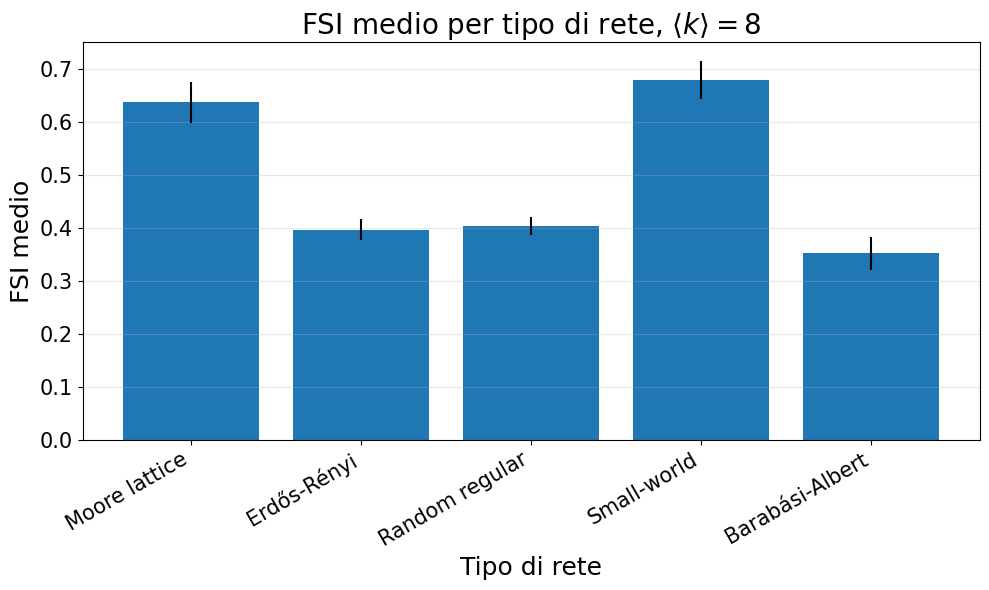

Saved: figures/comparison/ssi_degree8_barplot.png


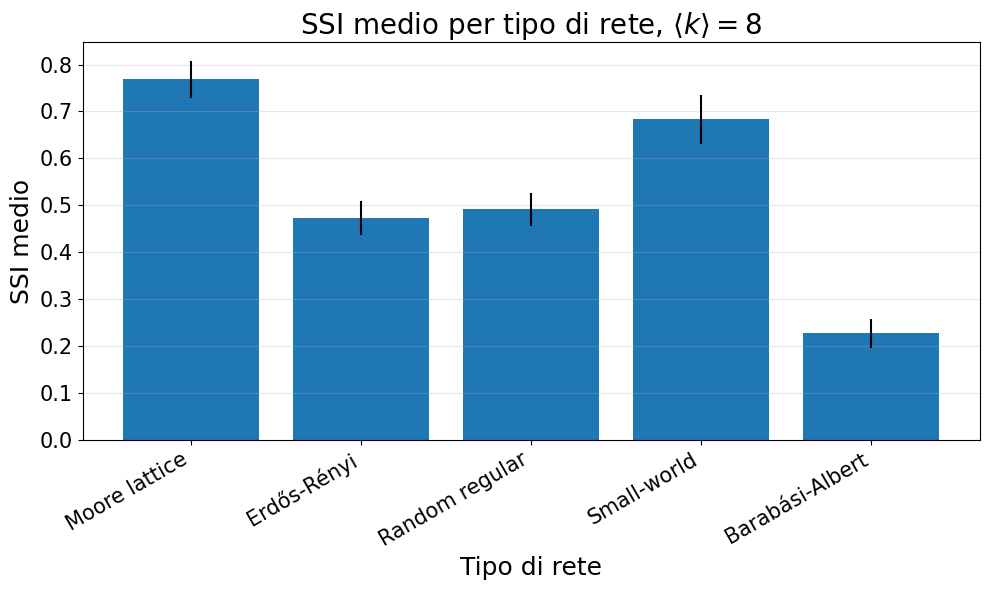

In [11]:
agg_df = load_aggregate_results("results")

degree8_df = select_degree_group(
    agg_df,
    degree=8,
    dynamics="nearest_unhappy",
    N=400,
    theta=0.10,
    similar_wanted=0.50,
)

plot_bar_index(degree8_df, index="freeman", degree=8)
plot_bar_index(degree8_df, index="ssi", degree=8)

## Degree-Preserving Rewiring

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

ALPHA_VALUES = [
    0.0,
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    1.0,
    2.0,
    5.0,
    10.0,
]


rewiring_cfg = Config(
    out_root="results_rewired_moore",
    fig_root="figures_rewired_moore",
    chk_root="checkpoints_rewired_moore",

    N=400,
    rows=20,
    cols=20,
    theta=0.10,
    similar_wanted=0.50,

    # Starting topology: Moore lattice
    network_type="rewired_moore",
    radius=1,

    # Dynamics
    dynamics="nearest_unhappy",

    # Monte Carlo
    max_sweeps=100,
    record_every_sweeps=1,
    stopping="no_moves_window",
    stop_window_sweeps=5,

    # Statistics
    network_instances=10,
    runs_per_network=10,
    base_seed=12345,

    # Saving
    resume=True,
    overwrite_completed=False,
    save_initial_state=True,
    save_final_state=True,
)


def alpha_tag(alpha):
    return f"alpha{str(alpha).replace('.', 'p')}"


def generate_moore_base_graph(cfg):
    """
    Generates the original square lattice with Moore neighbourhood.
    With radius=1, every node has degree 8.
    """
    if cfg.rows * cfg.cols != cfg.N:
        raise ValueError("For the Moore lattice, N must be equal to rows * cols.")

    G = generate_grid_moore(cfg.rows, cfg.cols, radius=cfg.radius)
    return nx.convert_node_labels_to_integers(G)


def degree_preserving_rewire(
    G0,
    alpha,
    seed=0,
    ensure_connected=True,
    max_retries=50,
):
    """
    Performs degree-preserving rewiring using double-edge swaps.

    alpha = average number of swaps per node
    n_swaps = round(alpha * N)

    The degree sequence is preserved exactly.
    """

    N = G0.number_of_nodes()
    n_swaps = int(round(alpha * N))

    if n_swaps == 0:
        return nx.convert_node_labels_to_integers(G0.copy())

    rng = np.random.default_rng(seed)

    for attempt in range(max_retries):
        G = G0.copy()

        swap_seed = int(rng.integers(0, 2**32 - 1))

        try:
            nx.double_edge_swap(
                G,
                nswap=n_swaps,
                max_tries=max(1000, 100 * n_swaps),
                seed=swap_seed,
            )
        except nx.NetworkXAlgorithmError:
            continue

        if ensure_connected:
            if nx.is_connected(G):
                return nx.convert_node_labels_to_integers(G)
        else:
            return nx.convert_node_labels_to_integers(G)

    raise RuntimeError(
        f"Could not generate a connected rewired graph for alpha={alpha}."
    )


def graph_topological_summary(G):
    """
    Computes basic topological quantities of the graph.
    """
    degrees = np.array([d for _, d in G.degree()], dtype=float)

    out = {
        "actual_avg_degree": float(degrees.mean()),
        "degree_std": float(degrees.std()),
        "degree_min": float(degrees.min()),
        "degree_max": float(degrees.max()),
        "average_clustering": float(nx.average_clustering(G)),
        "transitivity": float(nx.transitivity(G)),
        "edges": int(G.number_of_edges()),
        "connected": bool(nx.is_connected(G)),
    }

    if nx.is_connected(G):
        out["average_path_length"] = float(nx.average_shortest_path_length(G))
    else:
        out["average_path_length"] = np.nan

    return out


def run_single_on_given_graph(
    G,
    cfg,
    net_id,
    run_id,
    alpha,
    run_folder=None,
    save_timeseries=False,
):

    run_seed = cfg.base_seed + 10_000 * net_id + run_id
    rng = np.random.default_rng(run_seed)

    adj = graph_to_adj(G)

    # After rewiring, the network is no longer a geometric lattice.
    # Therefore the distance is the graph shortest-path distance.
    D = graph_distance_matrix(G)

    state = initial_state(cfg, rng)

    if run_folder is not None:
        run_folder = Path(run_folder)
        run_folder.mkdir(parents=True, exist_ok=True)

        if getattr(cfg, "save_initial_state", False):
            np.save(run_folder / "initial_state.npy", state.copy())

    rows = []
    no_move_sweeps = 0
    stable_counter = 0
    last_obs = None

    for sweep in range(1, cfg.max_sweeps + 1):

        moves = monte_carlo_sweep(state, adj, D, cfg, rng)

        if moves == 0:
            no_move_sweeps += 1
        else:
            no_move_sweeps = 0

        should_record = sweep == 1 or sweep % cfg.record_every_sweeps == 0

        if should_record:
            obs = observables(state, adj, G, cfg)
            obs["sweep"] = sweep
            obs["moves"] = moves
            rows.append(obs)

            if last_obs is not None:
                stable = (
                    abs(obs["mean_same"] - last_obs["mean_same"]) < cfg.stable_tol
                    and abs(obs["unhappy"] - last_obs["unhappy"]) < cfg.stable_tol
                    and abs(obs["freeman"] - last_obs["freeman"]) < cfg.stable_tol
                )

                if stable:
                    stable_counter += 1
                else:
                    stable_counter = 0

            last_obs = obs

            if cfg.stopping == "no_moves_window":
                if no_move_sweeps >= cfg.stop_window_sweeps:
                    break

            elif cfg.stopping == "stable_indices":
                if stable_counter >= cfg.stop_window_sweeps:
                    break

            elif cfg.stopping == "none":
                pass

            else:
                raise ValueError("Unknown stopping criterion.")

    df_ts = pd.DataFrame(rows)
    final = df_ts.iloc[-1].to_dict()

    if run_folder is not None:
        if getattr(cfg, "save_final_state", False):
            np.save(run_folder / "final_state.npy", state.copy())

        if save_timeseries:
            df_ts.to_csv(run_folder / "timeseries.csv", index=False)

    summary = {
        "alpha": alpha,
        "net_id": int(net_id),
        "run_id": int(run_id),
        "network_type": "rewired_moore",
        "dynamics": cfg.dynamics,
        "N": cfg.N,
        "theta": cfg.theta,
        "similar_wanted": cfg.similar_wanted,
        "final_sweep": int(sweep),
        "final_mean_same": final["mean_same"],
        "final_unhappy": final["unhappy"],
        "final_freeman": final["freeman"],
        "final_ssi": final["ssi"],
        "final_moves": final["moves"],
    }

    return summary, df_ts


def build_aggregate_from_alpha_df(df_alpha, alpha, cfg):
    total_runs = len(df_alpha)

    aggregate = {
        "alpha": alpha,
        "network_type": "rewired_moore",
        "dynamics": cfg.dynamics,
        "N": cfg.N,
        "theta": cfg.theta,
        "similar_wanted": cfg.similar_wanted,
        "network_instances": cfg.network_instances,
        "runs_per_network": cfg.runs_per_network,
        "total_runs": total_runs,

        "mean_actual_degree": df_alpha["actual_avg_degree"].mean(),
        "std_actual_degree": df_alpha["actual_avg_degree"].std(),

        "mean_clustering": df_alpha["average_clustering"].mean(),
        "std_clustering": df_alpha["average_clustering"].std(),

        "mean_transitivity": df_alpha["transitivity"].mean(),
        "std_transitivity": df_alpha["transitivity"].std(),

        "mean_path_length": df_alpha["average_path_length"].mean(),
        "std_path_length": df_alpha["average_path_length"].std(),

        "mean_final_same": df_alpha["final_mean_same"].mean(),
        "std_final_same": df_alpha["final_mean_same"].std(),

        "mean_final_unhappy": df_alpha["final_unhappy"].mean(),
        "std_final_unhappy": df_alpha["final_unhappy"].std(),

        "mean_final_freeman": df_alpha["final_freeman"].mean(),
        "std_final_freeman": df_alpha["final_freeman"].std(),

        "mean_final_ssi": df_alpha["final_ssi"].mean(),
        "std_final_ssi": df_alpha["final_ssi"].std(),

        "mean_final_sweep": df_alpha["final_sweep"].mean(),
        "std_final_sweep": df_alpha["final_sweep"].std(),
    }

    aggregate["sem_final_freeman"] = aggregate["std_final_freeman"] / np.sqrt(total_runs)
    aggregate["sem_final_ssi"] = aggregate["std_final_ssi"] / np.sqrt(total_runs)
    aggregate["sem_clustering"] = aggregate["std_clustering"] / np.sqrt(total_runs)

    return aggregate


def run_rewired_moore_alpha_sweep(
    alpha_values,
    cfg,
    save_timeseries=False,
    ensure_connected=True,
):
    out_root = Path(cfg.out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    base_G = generate_moore_base_graph(cfg)

    all_run_rows = []
    aggregate_rows = []
    network_rows = []

    for alpha in alpha_values:

        print("\n" + "=" * 70)
        print(f"Running alpha = {alpha}")
        print("=" * 70)

        alpha_folder = out_root / alpha_tag(alpha)
        alpha_folder.mkdir(parents=True, exist_ok=True)

        summary_file = alpha_folder / "summary_all.csv"
        aggregate_file = alpha_folder / "aggregate.csv"

        if (
            cfg.resume
            and not cfg.overwrite_completed
            and summary_file.exists()
        ):
            df_existing = pd.read_csv(summary_file)
            expected_runs = cfg.network_instances * cfg.runs_per_network

            if len(df_existing) >= expected_runs:
                print(f"alpha={alpha}: already completed. Skipping.")
                all_run_rows.extend(df_existing.to_dict("records"))

                if aggregate_file.exists():
                    aggregate_rows.append(pd.read_csv(aggregate_file).iloc[0].to_dict())

                continue

        alpha_run_rows = []

        for net_id in range(cfg.network_instances):

            net_seed = cfg.base_seed + 10_000 * net_id

            G = degree_preserving_rewire(
                base_G,
                alpha=alpha,
                seed=net_seed,
                ensure_connected=ensure_connected,
            )

            topo = graph_topological_summary(G)
            topo.update({
                "alpha": alpha,
                "net_id": int(net_id),
            })

            network_rows.append(topo)

            print(
                f"alpha={alpha} | network {net_id + 1}/{cfg.network_instances} | "
                f"C={topo['average_clustering']:.4f} | "
                f"L={topo['average_path_length']:.4f}"
            )

            for run_id in range(cfg.runs_per_network):

                run_folder = alpha_folder / f"net{net_id:03d}" / f"run{run_id:03d}"

                print(f"  running net={net_id}, run={run_id}")

                summary, df_ts = run_single_on_given_graph(
                    G=G,
                    cfg=cfg,
                    net_id=net_id,
                    run_id=run_id,
                    alpha=alpha,
                    run_folder=run_folder,
                    save_timeseries=save_timeseries,
                )

                summary.update(topo)

                alpha_run_rows.append(summary)
                all_run_rows.append(summary)

                # Incremental save, useful if the execution stops
                df_alpha_partial = pd.DataFrame(alpha_run_rows)
                df_alpha_partial.to_csv(summary_file, index=False)

        df_alpha = pd.DataFrame(alpha_run_rows)
        df_alpha = df_alpha.sort_values(["net_id", "run_id"]).reset_index(drop=True)
        df_alpha.to_csv(summary_file, index=False)

        aggregate = build_aggregate_from_alpha_df(df_alpha, alpha, cfg)
        pd.DataFrame([aggregate]).to_csv(aggregate_file, index=False)

        aggregate_rows.append(aggregate)

    df_all = pd.DataFrame(all_run_rows)
    df_agg = pd.DataFrame(aggregate_rows)
    df_networks = pd.DataFrame(network_rows)

    df_all.to_csv(out_root / "all_runs_rewired_moore.csv", index=False)
    df_agg.to_csv(out_root / "aggregate_rewired_moore.csv", index=False)
    df_networks.to_csv(out_root / "network_topology_rewired_moore.csv", index=False)

    print("\nSaved:")
    print(out_root / "all_runs_rewired_moore.csv")
    print(out_root / "aggregate_rewired_moore.csv")
    print(out_root / "network_topology_rewired_moore.csv")

    return df_all, df_agg, df_networks



def plot_clustering_vs_alpha(
    df_agg,
    error="sem",
    save_dir="figures_rewired_moore",
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    if error == "sem":
        yerr = df_agg["sem_clustering"]
    elif error == "std":
        yerr = df_agg["std_clustering"]
    elif error is None:
        yerr = None
    else:
        raise ValueError("error must be 'sem', 'std', or None.")

    plt.figure(figsize=(10, 6))

    plt.errorbar(
        df_agg["alpha"],
        df_agg["mean_clustering"],
        yerr=yerr,
        marker="o",
        capsize=0,
        linewidth=2,
    )

    plt.xlabel(r"Rewiring intensity $\alpha$  (swaps per node)", fontsize=18)
    plt.ylabel("Average clustering coefficient", fontsize=18)
    plt.title(r"Clustering vs degree-preserving rewiring, $\langle k\rangle=8$", fontsize=20)

    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    save_path = save_dir / "clustering_vs_alpha_rewired_moore.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()


def plot_alpha_result(
    df_agg,
    index="freeman",
    error="sem",
    save_dir="figures_rewired_moore",
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    if index == "freeman":
        mean_col = "mean_final_freeman"
        std_col = "std_final_freeman"
        sem_col = "sem_final_freeman"
        ylabel = "Final average FSI"
        title = r"Final average FSI vs degree-preserving rewiring, $\langle k\rangle=8$"
        filename = "fsi_vs_alpha_rewired_moore.png"

    elif index == "ssi":
        mean_col = "mean_final_ssi"
        std_col = "std_final_ssi"
        sem_col = "sem_final_ssi"
        ylabel = "Final average SSI"
        title = r"Final average SSI vs degree-preserving rewiring, $\langle k\rangle=8$"
        filename = "ssi_vs_alpha_rewired_moore.png"

    else:
        raise ValueError("index must be 'freeman' or 'ssi'.")

    if error == "sem":
        yerr = df_agg[sem_col]
    elif error == "std":
        yerr = df_agg[std_col]
    elif error is None:
        yerr = None
    else:
        raise ValueError("error must be 'sem', 'std', or None.")

    plt.figure(figsize=(10, 6))

    plt.errorbar(
        df_agg["alpha"],
        df_agg[mean_col],
        yerr=yerr,
        marker="o",
        capsize=0,
        linewidth=2,
    )

    plt.xlabel(r"Rewiring intensity $\alpha$  (swaps per node)", fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.title(title, fontsize=20)

    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    save_path = save_dir / filename
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()

def plot_index_vs_clustering(
    df_agg,
    index="freeman",
    save_dir="figures_rewired_moore",
):
    """
    Plots FSI or SSI against clustering with vertical error bars only.
    Error bars on y-axis = standard deviation of final FSI/SSI.
    No horizontal error bars.
    """

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    if index == "freeman":
        y_col = "mean_final_freeman"
        yerr_col = "std_final_freeman"
        ylabel = "FSI medio finale"
        title = "FSI medio finale vs clustering"
        filename = "fsi_vs_clustering_rewired_moore.png"

    elif index == "ssi":
        y_col = "mean_final_ssi"
        yerr_col = "std_final_ssi"
        ylabel = "SSI medio "
        title = "SSI medio  vs clustering"
        filename = "ssi_vs_clustering_rewired_moore.png"

    else:
        raise ValueError("index must be 'freeman' or 'ssi'.")

    plt.figure(figsize=(10, 6))

    plt.errorbar(
        df_agg["mean_clustering"],
        df_agg[y_col],
        yerr=df_agg[yerr_col],
        fmt="o",
        capsize=5,
        markersize=7,
        linewidth=2,
        elinewidth=1.5,
    )

    for _, row in df_agg.iterrows():
        plt.annotate(
            rf"$\alpha={row['alpha']}$",
            (row["mean_clustering"], row[y_col]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=11,
        )

    plt.xlabel("Coefficiente medio di clustering", fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.title(title, fontsize=20)

    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    save_path = save_dir / filename
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()


In [ ]:
df_all_rewired, df_agg_rewired, df_networks_rewired = run_rewired_moore_alpha_sweep(
    alpha_values=ALPHA_VALUES,
    cfg=rewiring_cfg,
    save_timeseries=False,
    ensure_connected=True,
)

display(df_agg_rewired)


Running alpha = 0.0
alpha=0.0 | network 1/10 | C=0.4286 | L=6.6917
  running net=0, run=0
  running net=0, run=1
  running net=0, run=2
  running net=0, run=3
  running net=0, run=4
  running net=0, run=5
  running net=0, run=6
  running net=0, run=7
  running net=0, run=8
  running net=0, run=9
alpha=0.0 | network 2/10 | C=0.4286 | L=6.6917
  running net=1, run=0
  running net=1, run=1
  running net=1, run=2
  running net=1, run=3
  running net=1, run=4
  running net=1, run=5
  running net=1, run=6
  running net=1, run=7
  running net=1, run=8
  running net=1, run=9
alpha=0.0 | network 3/10 | C=0.4286 | L=6.6917
  running net=2, run=0
  running net=2, run=1
  running net=2, run=2
  running net=2, run=3
  running net=2, run=4
  running net=2, run=5
  running net=2, run=6
  running net=2, run=7
  running net=2, run=8
  running net=2, run=9
alpha=0.0 | network 4/10 | C=0.4286 | L=6.6917
  running net=3, run=0
  running net=3, run=1
  running net=3, run=2
  running net=3, run=3
  running

,alpha,network_type,dynamics,N,theta,similar_wanted,network_instances,runs_per_network,total_runs,mean_actual_degree,...,std_final_unhappy,mean_final_freeman,std_final_freeman,mean_final_ssi,std_final_ssi,mean_final_sweep,std_final_sweep,sem_final_freeman,sem_final_ssi,sem_clustering
0,0.00,rewired_moore,nearest_unhappy,400,0.1,0.5,10,10,100,8.0,...,0.003690,0.635527,0.034748,0.765961,0.037965,14.23,2.722354,0.003475,0.003797,5.579081e-18
1,0.05,rewired_moore,nearest_unhappy,400,0.1,0.5,10,10,100,8.0,...,0.006204,0.624263,0.038608,0.748406,0.038644,14.17,2.678214,0.003861,0.003864,2.156343e-04
2,0.10,rewired_moore,nearest_unhappy,400,0.1,0.5,10,10,100,8.0,...,0.001926,0.613475,0.040951,0.724486,0.038253,13.67,2.387065,0.004095,0.003825,3.126623e-04
3,0.20,rewired_moore,nearest_unhappy,400,0.1,0.5,10,10,100,8.0,...,0.004741,0.592654,0.037708,0.696465,0.037616,13.47,2.199426,0.003771,0.003762,2.465115e-04
4,0.30,rewired_moore,nearest_unhappy,400,0.1,0.5,10,10,100,8.0,...,0.004356,0.572448,0.030944,0.668931,0.036007,13.45,2.746439,0.003094,0.003601,3.865341e-04
5,0.40,rewired_moore,nearest_unhappy,400,0.1,0.5,10,10,100,8.0,...,0.004943,0.555363,0.033302,0.643738,0.036159,13.57,2.297363,0.003330,0.003616,5.600273e-04
6,0.50,rewired_moore,nearest_unhappy,400,0.1,0.5,10,10,100,8.0,...,0.005554,0.534425,0.033862,0.626084,0.033770,13.36,2.190521,0.003386,0.003377,6.401458e-04
7,0.60,rewired_moore,nearest_unhappy,400,0.1,0.5,10,10,100,8.0,...,0.003699,0.518232,0.030237,0.610134,0.038031,13.46,2.442966,0.003024,0.003803,7.121315e-04
8,0.70,rewired_moore,nearest_unhappy,400,0.1,0.5,10,10,100,8.0,...,0.004574,0.499415,0.028908,0.583408,0.035296,13.46,2.061773,0.002891,0.003530,6.345742e-04
9,0.80,rewired_moore,nearest_unhappy,400,0.1,0.5,10,10,100,8.0,...,0.004621,0.489512,0.027708,0.574755,0.042376,13.60,2.201928,0.002771,0.004238,6.125204e-04


Saved: figures_rewired_moore\fsi_vs_clustering_rewired_moore.png


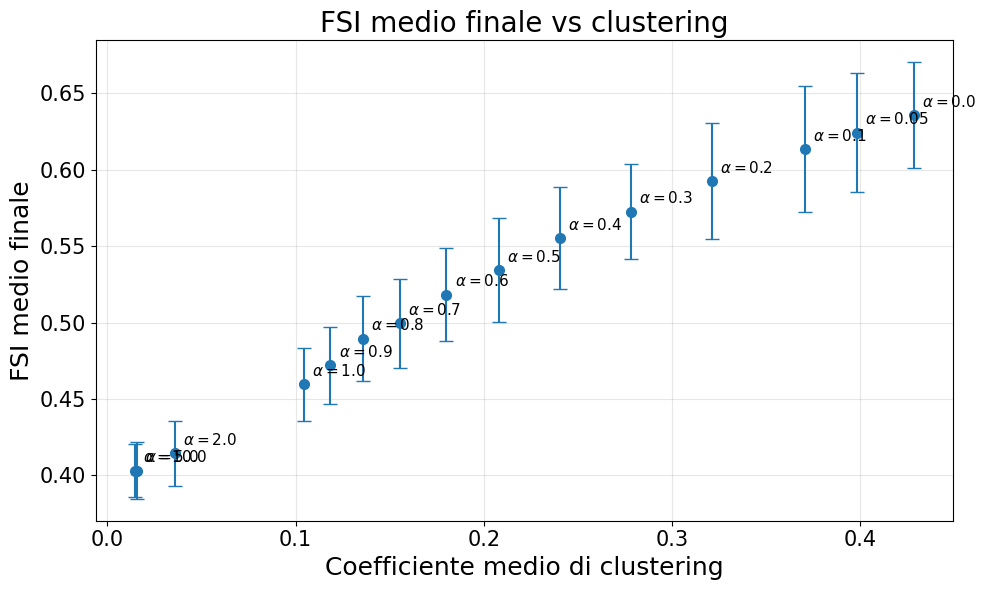

Saved: figures_rewired_moore\ssi_vs_clustering_rewired_moore.png


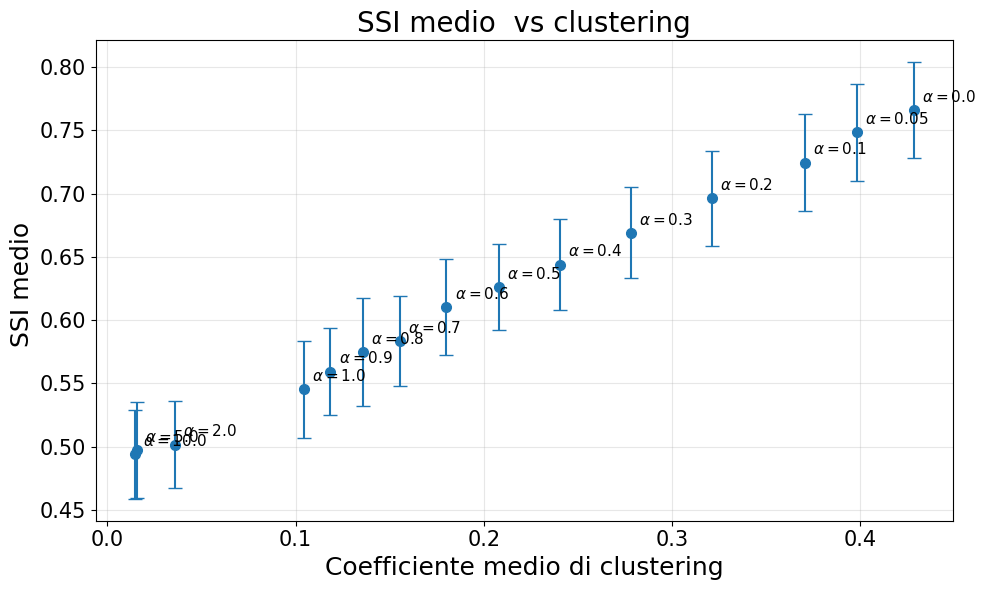

In [26]:
plot_index_vs_clustering(
    df_agg_rewired,
    index="freeman",
    save_dir=rewiring_cfg.fig_root,
)

plot_index_vs_clustering(
    df_agg_rewired,
    index="ssi",
    save_dir=rewiring_cfg.fig_root,
)

In [27]:
def plot_clustering_vs_alpha_logx(
    df_agg,
    error="sem",
    save_dir="figures_rewired_moore",
):
    """
    Plots average clustering as a function of alpha
    with logarithmic scale on the x-axis.

    Since log(0) is undefined, alpha = 0 is excluded from this plot.
    """

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    df_plot = df_agg[df_agg["alpha"] > 0].copy()

    if error == "sem":
        yerr = df_plot["sem_clustering"]
    elif error == "std":
        yerr = df_plot["std_clustering"]
    elif error is None:
        yerr = None
    else:
        raise ValueError("error must be 'sem', 'std', or None.")

    plt.figure(figsize=(10, 6))

    plt.errorbar(
        df_plot["alpha"],
        df_plot["mean_clustering"],
        yerr=yerr,
        marker="o",
        capsize=0,
        linewidth=2,
    )

    plt.xscale("log")

    plt.xlabel(r"Intensità di rewiring $\alpha$ (swap per nodo)", fontsize=18)
    plt.ylabel("Coefficiente medio di clustering", fontsize=18)
    plt.title(
        r"Clustering vs rewiring degree-preserving, $\langle k\rangle=8$",
        fontsize=20,
    )

    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(alpha=0.3, which="both")
    plt.tight_layout()

    save_path = save_dir / "clustering_vs_alpha_logx_rewired_moore.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()

ALPHA_VALUES_EXTENDED = [
    0.0,
    0.01,
    0.02,
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.70,
    1.0,
    1.5,
    2.0,
    3.0,
    5.0,
    7.0,
    10.0,
    20.0,
    50.0,
    100.0,
]

rewiring_cfg.resume = True
rewiring_cfg.overwrite_completed = False

df_all_rewired, df_agg_rewired, df_networks_rewired = run_rewired_moore_alpha_sweep(
    alpha_values=ALPHA_VALUES_EXTENDED,
    cfg=rewiring_cfg,
    save_timeseries=False,
    ensure_connected=True,
)


Running alpha = 0.0
alpha=0.0: already completed. Skipping.

Running alpha = 0.01
alpha=0.01 | network 1/10 | C=0.4216 | L=6.0684
  running net=0, run=0
  running net=0, run=1
  running net=0, run=2
  running net=0, run=3
  running net=0, run=4
  running net=0, run=5
  running net=0, run=6
  running net=0, run=7
  running net=0, run=8
  running net=0, run=9
alpha=0.01 | network 2/10 | C=0.4229 | L=6.2866
  running net=1, run=0
  running net=1, run=1
  running net=1, run=2
  running net=1, run=3
  running net=1, run=4
  running net=1, run=5
  running net=1, run=6
  running net=1, run=7
  running net=1, run=8
  running net=1, run=9
alpha=0.01 | network 3/10 | C=0.4227 | L=6.1405
  running net=2, run=0
  running net=2, run=1
  running net=2, run=2
  running net=2, run=3
  running net=2, run=4
  running net=2, run=5
  running net=2, run=6
  running net=2, run=7
  running net=2, run=8
  running net=2, run=9
alpha=0.01 | network 4/10 | C=0.4221 | L=6.2161
  running net=3, run=0
  running ne

Saved: figures_rewired_moore\clustering_vs_alpha_logx_rewired_moore.png


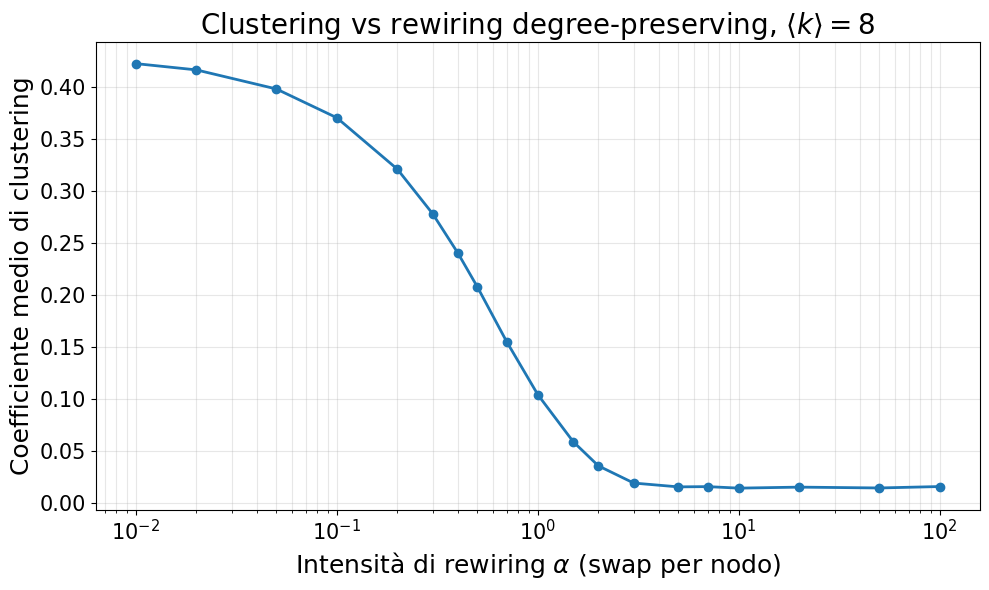

In [28]:
plot_clustering_vs_alpha_logx(
    df_agg_rewired,
    error="sem",
    save_dir=rewiring_cfg.fig_root,
)

## Sensitivity Analysis

In [ ]:
from pathlib import Path
import pandas as pd


def run_vn_sensitivity(
    radius_values=[1, 2, 3, 4],
    theta_values=[0.10, 0.20, 0.30, 0.40, 0.50],
    N=400,
    rows=20,
    cols=20,
    similar_wanted=0.50,
    dynamics="nearest_unhappy",
    max_sweeps=100,
    record_every_sweeps=1,
    stopping="no_moves_window",
    stop_window_sweeps=30,
    network_instances=1,
    runs_per_network=10,
    base_seed=12345,
    overwrite_completed=False,
    output_csv="results/sensitivity/vn_radius_theta_sensitivity.csv",
):
    output_path = Path(output_csv)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    # Load old sensitivity results if present
    if output_path.exists():
        old_df = pd.read_csv(output_path)
        results = old_df.to_dict("records")
        print(f"Loaded existing sensitivity table: {output_path}")
    else:
        results = []
        print("No existing sensitivity table found. Creating a new one.")

    for r in radius_values:
        for theta in theta_values:

            degree = 2 * r * (r + 1)

            cfg = Config(
                N=N,
                rows=rows,
                cols=cols,

                theta=theta,
                similar_wanted=similar_wanted,

                network_type="grid_vn",
                radius=r,

                dynamics=dynamics,

                max_sweeps=max_sweeps,
                record_every_sweeps=record_every_sweeps,

                stopping=stopping,
                stop_window_sweeps=stop_window_sweeps,

                network_instances=network_instances,
                runs_per_network=runs_per_network,

                base_seed=base_seed,

                overwrite_completed=overwrite_completed,
            )

            print(
                f"\nVN lattice | radius={r} | degree={degree} | "
                f"theta={theta} | overwrite={overwrite_completed}"
            )

            df, aggregate = run_experiment(cfg)

            aggregate["radius"] = r
            aggregate["theta"] = theta
            aggregate["degree"] = degree

            results.append(aggregate)

            # Save progressively after every point
            temp_df = pd.DataFrame(results)

            # Remove old duplicate entries for same parameter point
            temp_df = temp_df.drop_duplicates(
                subset=[
                    "network_type",
                    "dynamics",
                    "N",
                    "theta",
                    "similar_wanted",
                    "radius",
                    "degree",
                ],
                keep="last",
            )

            temp_df = temp_df.sort_values(["theta", "radius"])
            temp_df.to_csv(output_path, index=False)

            results = temp_df.to_dict("records")

            print(f"Updated table saved to: {output_path}")

    final_df = pd.DataFrame(results)
    final_df = final_df.sort_values(["theta", "radius"])

    final_df.to_csv(output_path, index=False)

    return final_df

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

vn_df = pd.read_csv("results/sensitivity/vn_radius_theta_sensitivity.csv")

vn_df.head()

def plot_index_vs_degree_by_theta(
    df,
    index_col,
    ylabel,
    title,
    save_path=None
):
    theta_values = sorted(df["theta"].unique())

    plt.figure(figsize=(8, 5))

    for theta in theta_values:
        sub = df[df["theta"] == theta].sort_values("degree")

        plt.plot(
            sub["degree"],
            sub[index_col],
            marker="o",
            linewidth=2,
            label=f"θ = {theta}"
        )

    plt.xlabel("Average degree")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(title="Empty fraction")
    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300)
        print(f"Saved: {save_path}")

    plt.show()
    

# DEGREE HELPERS

def vn_degree(r):
    return 2 * r * (r + 1)

def moore_degree(r):
    return (2 * r + 1)**2 - 1

def build_degree_grid(vn_radii=[1,2,3,4], moore_radii=[1,2,3]):
    degrees = set()

    for r in vn_radii:
        degrees.add(vn_degree(r))

    for r in moore_radii:
        degrees.add(moore_degree(r))

    return sorted(degrees)



def run_moore_sensitivity(
    radius_values=[1, 2, 3],
    theta_values=[0.10, 0.20, 0.30, 0.40, 0.50],
    N=400,
    rows=20,
    cols=20,
    similar_wanted=0.50,
    dynamics="nearest_unhappy",
    max_sweeps=100,
    record_every_sweeps=1,
    stopping="no_moves_window",
    stop_window_sweeps=30,
    network_instances=1,
    runs_per_network=10,
    base_seed=12345,
    overwrite_completed=False,
    output_csv="results/sensitivity/moore_radius_theta_sensitivity.csv",
):
    output_path = Path(output_csv)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        results = pd.read_csv(output_path).to_dict("records")
    else:
        results = []

    for r in radius_values:
        for theta in theta_values:

            degree = moore_degree(r)

            cfg = Config(
                N=N,
                rows=rows,
                cols=cols,

                theta=theta,
                similar_wanted=similar_wanted,

                network_type="grid_moore",
                radius=r,

                dynamics=dynamics,

                max_sweeps=max_sweeps,
                record_every_sweeps=record_every_sweeps,

                stopping=stopping,
                stop_window_sweeps=stop_window_sweeps,

                network_instances=network_instances,
                runs_per_network=runs_per_network,

                base_seed=base_seed,
                overwrite_completed=overwrite_completed,
            )

            print(
                f"\nMoore lattice | radius={r} | degree={degree} | "
                f"theta={theta} | overwrite={overwrite_completed}"
            )

            df, aggregate = run_experiment(cfg)

            aggregate["radius"] = r
            aggregate["theta"] = theta
            aggregate["degree"] = degree
            aggregate["target_degree"] = degree

            results.append(aggregate)

            temp_df = pd.DataFrame(results)

            temp_df = temp_df.drop_duplicates(
                subset=[
                    "network_type",
                    "dynamics",
                    "N",
                    "theta",
                    "similar_wanted",
                    "radius",
                    "degree",
                ],
                keep="last",
            )

            temp_df = temp_df.sort_values(["theta", "radius"])
            temp_df.to_csv(output_path, index=False)

            results = temp_df.to_dict("records")

    final_df = pd.DataFrame(results).sort_values(["theta", "radius"])
    final_df.to_csv(output_path, index=False)

    return final_df

def run_degree_based_sensitivity(
    network_type,
    degree_values,
    theta_values=[0.10, 0.20, 0.30, 0.40, 0.50],
    N=400,
    similar_wanted=0.50,
    dynamics="nearest_unhappy",
    beta=0.10,
    max_sweeps=100,
    record_every_sweeps=1,
    stopping="no_moves_window",
    stop_window_sweeps=30,
    network_instances=1,
    runs_per_network=10,
    base_seed=12345,
    overwrite_completed=False,
    output_csv=None,
):
    if output_csv is None:
        output_csv = f"results/sensitivity/{network_type}_degree_theta_sensitivity.csv"

    output_path = Path(output_csv)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        results = pd.read_csv(output_path).to_dict("records")
        print(f"Loaded existing table: {output_path}")
    else:
        results = []
        print("No existing table found. Creating a new one.")

    for degree in degree_values:
        for theta in theta_values:

            if degree >= N:
                print(f"Skipping degree={degree}: degree must be < N")
                continue

        

            if network_type == "erdos_renyi":
                cfg = Config(
                    N=N,
                    theta=theta,
                    similar_wanted=similar_wanted,

                    network_type="erdos_renyi",
                    avg_degree=degree,
                    p=None,

                    dynamics=dynamics,

                    max_sweeps=max_sweeps,
                    record_every_sweeps=record_every_sweeps,

                    stopping=stopping,
                    stop_window_sweeps=stop_window_sweeps,

                    network_instances=network_instances,
                    runs_per_network=runs_per_network,

                    base_seed=base_seed,
                    overwrite_completed=overwrite_completed,
                )

            elif network_type == "random_regular":
                if degree * N % 2 != 0:
                    print(f"Skipping degree={degree}: degree*N must be even")
                    continue

                cfg = Config(
                    N=N,
                    theta=theta,
                    similar_wanted=similar_wanted,

                    network_type="random_regular",
                    regular_degree=degree,

                    dynamics=dynamics,

                    max_sweeps=max_sweeps,
                    record_every_sweeps=record_every_sweeps,

                    stopping=stopping,
                    stop_window_sweeps=stop_window_sweeps,

                    network_instances=network_instances,
                    runs_per_network=runs_per_network,

                    base_seed=base_seed,
                    overwrite_completed=overwrite_completed,
                )

            elif network_type == "ring_sw":
                if degree % 2 != 0:
                    print(f"Skipping degree={degree}: Watts-Strogatz k must be even")
                    continue

                cfg = Config(
                    N=N,
                    theta=theta,
                    similar_wanted=similar_wanted,

                    network_type="ring_sw",
                    k=degree,
                    beta=beta,

                    dynamics=dynamics,

                    max_sweeps=max_sweeps,
                    record_every_sweeps=record_every_sweeps,

                    stopping=stopping,
                    stop_window_sweeps=stop_window_sweeps,

                    network_instances=network_instances,
                    runs_per_network=runs_per_network,

                    base_seed=base_seed,
                    overwrite_completed=overwrite_completed,
                )

            elif network_type == "barabasi_albert":
                if degree % 2 != 0:
                    print(f"Skipping degree={degree}: BA average degree is approximately 2m")
                    continue

                m = degree // 2

                if m < 1 or m >= N:
                    print(f"Skipping degree={degree}: invalid BA m={m}")
                    continue

                cfg = Config(
                    N=N,
                    theta=theta,
                    similar_wanted=similar_wanted,

                    network_type="barabasi_albert",
                    ba_m=m,

                    dynamics=dynamics,

                    max_sweeps=max_sweeps,
                    record_every_sweeps=record_every_sweeps,

                    stopping=stopping,
                    stop_window_sweeps=stop_window_sweeps,

                    network_instances=network_instances,
                    runs_per_network=runs_per_network,

                    base_seed=base_seed,
                    overwrite_completed=overwrite_completed,
                )

            else:
                raise ValueError(
                    "network_type must be 'erdos_renyi', "
                    "'random_regular', 'ring_sw', or 'barabasi_albert'"
                )

            print(
                f"\n{network_type} | target degree={degree} | "
                f"theta={theta} | overwrite={overwrite_completed}"
            )

            df, aggregate = run_experiment(cfg)

            aggregate["theta"] = theta
            aggregate["target_degree"] = degree
            aggregate["degree"] = degree

            if network_type == "barabasi_albert":
                aggregate["ba_m"] = degree // 2

            if network_type == "ring_sw":
                aggregate["beta"] = beta

            results.append(aggregate)

            temp_df = pd.DataFrame(results)

            duplicate_cols = [
                "network_type",
                "dynamics",
                "N",
                "theta",
                "similar_wanted",
                "target_degree",
            ]

            if "beta" in temp_df.columns:
                duplicate_cols.append("beta")

            temp_df = temp_df.drop_duplicates(
                subset=duplicate_cols,
                keep="last",
            )

            temp_df = temp_df.sort_values(["theta", "target_degree"])
            temp_df.to_csv(output_path, index=False)

            results = temp_df.to_dict("records")

            print(f"Updated table saved to: {output_path}")

    final_df = pd.DataFrame(results).sort_values(["theta", "target_degree"])
    final_df.to_csv(output_path, index=False)

    return final_df



def plot_index_vs_theta_by_degree(
    df,
    index_col,
    ylabel,
    title,
    degree_col="degree",
    save_path=None,
):
    """
    Plot dell'indice di segregazione in funzione di theta,
    separando le curve per grado della rete.
    Titoli, assi e legenda in italiano.
    """

    plt.figure(figsize=(10, 6))

    for degree in sorted(df[degree_col].dropna().unique()):
        sub = df[df[degree_col] == degree].sort_values("theta")

        plt.plot(
            sub["theta"],
            sub[index_col],
            marker="o",
            linewidth=2.5,
            markersize=7,
            label=rf"$\langle k\rangle={degree}$",
        )

    plt.xlabel(r"Frazione di siti vuoti $\theta$", fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.title(title, fontsize=20)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.grid(alpha=0.3)
    plt.legend(title="Grado medio", fontsize=12, title_fontsize=13)

    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

In [38]:
moore_df = run_moore_sensitivity(
    radius_values=[1, 2, 3],
    theta_values=[0.10, 0.20, 0.30, 0.40, 0.50],
    overwrite_completed=False,
)

moore_df


Moore lattice | radius=1 | degree=8 | theta=0.1 | overwrite=False
Network 1/1 | Run 1/10
Network 1/1 | Run 2/10
Network 1/1 | Run 3/10
Network 1/1 | Run 4/10
Network 1/1 | Run 5/10
Network 1/1 | Run 6/10
Network 1/1 | Run 7/10
Network 1/1 | Run 8/10
Network 1/1 | Run 9/10
Network 1/1 | Run 10/10

Moore lattice | radius=1 | degree=8 | theta=0.2 | overwrite=False
Network 1/1 | Run 1/10
Network 1/1 | Run 2/10
Network 1/1 | Run 3/10
Network 1/1 | Run 4/10
Network 1/1 | Run 5/10
Network 1/1 | Run 6/10
Network 1/1 | Run 7/10
Network 1/1 | Run 8/10
Network 1/1 | Run 9/10
Network 1/1 | Run 10/10

Moore lattice | radius=1 | degree=8 | theta=0.3 | overwrite=False
Network 1/1 | Run 1/10
Network 1/1 | Run 2/10
Network 1/1 | Run 3/10
Network 1/1 | Run 4/10
Network 1/1 | Run 5/10
Network 1/1 | Run 6/10
Network 1/1 | Run 7/10
Network 1/1 | Run 8/10
Network 1/1 | Run 9/10
Network 1/1 | Run 10/10

Moore lattice | radius=1 | degree=8 | theta=0.4 | overwrite=False
Network 1/1 | Run 1/10
Network 1/1 | Ru

,network_type,dynamics,N,theta,similar_wanted,network_instances,runs_per_network,total_runs,mean_final_same,std_final_same,...,std_final_unhappy,mean_final_freeman,std_final_freeman,mean_final_ssi,std_final_ssi,mean_actual_degree,mean_final_sweep,radius,degree,target_degree
0,grid_moore,nearest_unhappy,400,0.1,0.5,1,10,10,0.821269,0.018485,...,0.004024,0.637169,0.038679,0.774020,0.047545,8.0,39.3,1,8,8
1,grid_moore,nearest_unhappy,400,0.1,0.5,1,10,10,0.828423,0.036155,...,0.010228,0.652057,0.072020,0.695078,0.046886,24.0,40.8,2,24,24
2,grid_moore,nearest_unhappy,400,0.1,0.5,1,10,10,0.792603,0.020964,...,0.016832,0.582677,0.041423,0.656237,0.033657,48.0,40.5,3,48,48
3,grid_moore,nearest_unhappy,400,0.2,0.5,1,10,10,0.795080,0.011656,...,0.000000,0.581170,0.019333,0.674766,0.030700,8.0,38.0,1,8,8
4,grid_moore,nearest_unhappy,400,0.2,0.5,1,10,10,0.792815,0.033847,...,0.000000,0.570903,0.063900,0.597679,0.051642,24.0,38.1,2,24,24
5,grid_moore,nearest_unhappy,400,0.2,0.5,1,10,10,0.758511,0.019514,...,0.006105,0.506137,0.036349,0.584849,0.052456,48.0,38.6,3,48,48
6,grid_moore,nearest_unhappy,400,0.3,0.5,1,10,10,0.794871,0.019452,...,0.000000,0.573361,0.037483,0.647808,0.015264,8.0,38.5,1,8,8
7,grid_moore,nearest_unhappy,400,0.3,0.5,1,10,10,0.759816,0.020707,...,0.000000,0.501677,0.034597,0.576778,0.041766,24.0,38.4,2,24,24
8,grid_moore,nearest_unhappy,400,0.3,0.5,1,10,10,0.743896,0.014945,...,0.000000,0.472899,0.027975,0.566567,0.039505,48.0,38.9,3,48,48
9,grid_moore,nearest_unhappy,400,0.4,0.5,1,10,10,0.786690,0.012817,...,0.000000,0.554504,0.027393,0.683564,0.034286,8.0,35.9,1,8,8


Saved: figures/sensitivity/moore_fsi_vs_theta_by_degree.png


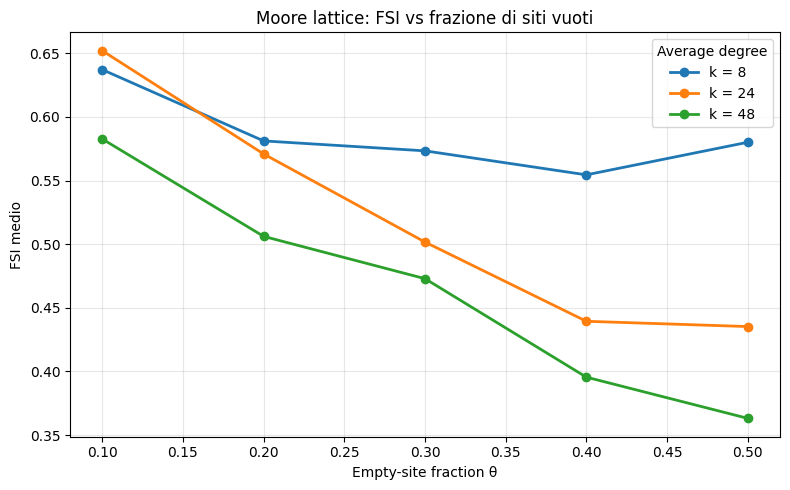

Saved: figures/sensitivity/moore_ssi_vs_theta_by_degree.png


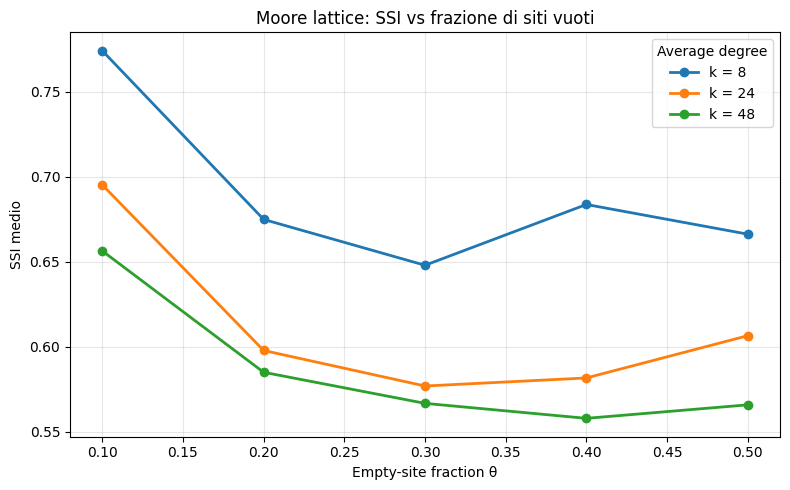

In [40]:
plot_index_vs_theta_by_degree(
    df=moore_df,
    index_col="mean_final_freeman",
    ylabel="FSI medio",
    title=r"Moore lattice: FSI vs frazione di siti vuoti",
    degree_col="degree",
    save_path="figures/sensitivity/moore_fsi_vs_theta_by_degree.png"
)

plot_index_vs_theta_by_degree(
    df=moore_df,
    index_col="mean_final_ssi",
    ylabel="SSI medio",
    title=r"Moore lattice: SSI vs frazione di siti vuoti",
    degree_col="degree",
    save_path="figures/sensitivity/moore_ssi_vs_theta_by_degree.png"
)

## Network Size Analysis

In [ ]:
# NETWORK SIZE SENSITIVITY AT FIXED DENSITY d/N

from pathlib import Path
import numpy as np
import pandas as pd


def nearest_even_integer(x):
    k = int(round(x))
    if k % 2 != 0:
        k += 1
    return k


def run_size_density_sensitivity(
    network_type="erdos_renyi",
    N_values=list(range(100, 1001, 100)),
    density_values=[0.04, 0.12, 0.24, 0.48],
    theta=0.10,
    similar_wanted=0.50,
    dynamics="nearest_unhappy",
    beta=0.10,
    max_sweeps=100,
    record_every_sweeps=1,
    stopping="no_moves_window",
    stop_window_sweeps=30,
    network_instances=1,
    runs_per_network=10,
    base_seed=12345,
    overwrite_completed=False,
    output_csv=None,
):
    if output_csv is None:
        output_csv = f"results/sensitivity/{network_type}_size_density_sensitivity.csv"

    output_path = Path(output_csv)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        results = pd.read_csv(output_path).to_dict("records")
        print(f"Loaded existing table: {output_path}")
    else:
        results = []
        print("No existing table found. Creating a new one.")

    for N in N_values:
        for density in density_values:

            target_degree_raw = density * N

            # For these models, degree must usually be integer/even
            target_degree = nearest_even_integer(target_degree_raw)

            if target_degree >= N:
                print(f"Skipping N={N}, density={density}: degree >= N")
                continue

            if target_degree < 1:
                print(f"Skipping N={N}, density={density}: degree < 1")
                continue

            # -------------------------
            # Build network-specific config
            # -------------------------

            if network_type == "erdos_renyi":
                cfg = Config(
                    N=N,
                    theta=theta,
                    similar_wanted=similar_wanted,

                    network_type="erdos_renyi",
                    avg_degree=target_degree,
                    p=None,

                    dynamics=dynamics,

                    max_sweeps=max_sweeps,
                    record_every_sweeps=record_every_sweeps,

                    stopping=stopping,
                    stop_window_sweeps=stop_window_sweeps,

                    network_instances=network_instances,
                    runs_per_network=runs_per_network,

                    base_seed=base_seed,
                    overwrite_completed=overwrite_completed,
                )

            elif network_type == "random_regular":
                cfg = Config(
                    N=N,
                    theta=theta,
                    similar_wanted=similar_wanted,

                    network_type="random_regular",
                    regular_degree=target_degree,

                    dynamics=dynamics,

                    max_sweeps=max_sweeps,
                    record_every_sweeps=record_every_sweeps,

                    stopping=stopping,
                    stop_window_sweeps=stop_window_sweeps,

                    network_instances=network_instances,
                    runs_per_network=runs_per_network,

                    base_seed=base_seed,
                    overwrite_completed=overwrite_completed,
                )

            elif network_type == "ring_sw":
                cfg = Config(
                    N=N,
                    theta=theta,
                    similar_wanted=similar_wanted,

                    network_type="ring_sw",
                    k=target_degree,
                    beta=beta,

                    dynamics=dynamics,

                    max_sweeps=max_sweeps,
                    record_every_sweeps=record_every_sweeps,

                    stopping=stopping,
                    stop_window_sweeps=stop_window_sweeps,

                    network_instances=network_instances,
                    runs_per_network=runs_per_network,

                    base_seed=base_seed,
                    overwrite_completed=overwrite_completed,
                )

            elif network_type == "barabasi_albert":
                # BA has avg degree ≈ 2m
                m = max(1, target_degree // 2)

                cfg = Config(
                    N=N,
                    theta=theta,
                    similar_wanted=similar_wanted,

                    network_type="barabasi_albert",
                    ba_m=m,

                    dynamics=dynamics,

                    max_sweeps=max_sweeps,
                    record_every_sweeps=record_every_sweeps,

                    stopping=stopping,
                    stop_window_sweeps=stop_window_sweeps,

                    network_instances=network_instances,
                    runs_per_network=runs_per_network,

                    base_seed=base_seed,
                    overwrite_completed=overwrite_completed,
                )

            else:
                raise ValueError(
                    "network_type must be 'erdos_renyi', "
                    "'random_regular', 'ring_sw', or 'barabasi_albert'"
                )

            print(
                f"\n{network_type} | N={N} | density={density} | "
                f"target degree={target_degree} | overwrite={overwrite_completed}"
            )

            df, aggregate = run_experiment(cfg)

            aggregate["N"] = N
            aggregate["density"] = density
            aggregate["target_degree_raw"] = target_degree_raw
            aggregate["target_degree"] = target_degree

            if network_type == "barabasi_albert":
                aggregate["ba_m"] = m

            if network_type == "ring_sw":
                aggregate["beta"] = beta

            results.append(aggregate)

            temp_df = pd.DataFrame(results)

            duplicate_cols = [
                "network_type",
                "dynamics",
                "N",
                "theta",
                "similar_wanted",
                "density",
                "target_degree",
            ]

            if "beta" in temp_df.columns:
                duplicate_cols.append("beta")

            temp_df = temp_df.drop_duplicates(
                subset=duplicate_cols,
                keep="last"
            )

            temp_df = temp_df.sort_values(["density", "N"])
            temp_df.to_csv(output_path, index=False)

            results = temp_df.to_dict("records")

            print(f"Updated table saved to: {output_path}")

    final_df = pd.DataFrame(results).sort_values(["density", "N"])
    final_df.to_csv(output_path, index=False)

    return final_df

In [46]:
er_size_df = run_size_density_sensitivity(
    network_type="erdos_renyi",
    N_values=list(range(100, 1001, 100)),
    density_values=[0.04, 0.12, 0.24, 0.48],
    theta=0.10,
    network_instances=1,
    runs_per_network=10,
    overwrite_completed=False,
)

er_size_df

Loaded existing table: results\sensitivity\erdos_renyi_size_density_sensitivity.csv

erdos_renyi | N=100 | density=0.04 | target degree=4 | overwrite=False
Network 1/1 | Run 1/10
Network 1/1 | Run 2/10
Network 1/1 | Run 3/10
Network 1/1 | Run 4/10
Network 1/1 | Run 5/10
Network 1/1 | Run 6/10
Network 1/1 | Run 7/10
Network 1/1 | Run 8/10
Network 1/1 | Run 9/10
Network 1/1 | Run 10/10
Updated table saved to: results\sensitivity\erdos_renyi_size_density_sensitivity.csv

erdos_renyi | N=100 | density=0.12 | target degree=12 | overwrite=False
Network 1/1 | Run 1/10
Network 1/1 | Run 2/10
Network 1/1 | Run 3/10
Network 1/1 | Run 4/10
Network 1/1 | Run 5/10
Network 1/1 | Run 6/10
Network 1/1 | Run 7/10
Network 1/1 | Run 8/10
Network 1/1 | Run 9/10
Network 1/1 | Run 10/10
Updated table saved to: results\sensitivity\erdos_renyi_size_density_sensitivity.csv

erdos_renyi | N=100 | density=0.24 | target degree=24 | overwrite=False
Network 1/1 | Run 1/10
Network 1/1 | Run 2/10
Network 1/1 | Run 3/

,network_type,dynamics,N,theta,similar_wanted,network_instances,runs_per_network,total_runs,mean_final_same,std_final_same,...,std_final_unhappy,mean_final_freeman,std_final_freeman,mean_final_ssi,std_final_ssi,mean_actual_degree,mean_final_sweep,density,target_degree_raw,target_degree
0,erdos_renyi,nearest_unhappy,100,0.1,0.5,1,10,10,0.778445,0.028399,...,0.025139,0.502174,0.063966,0.585196,0.030347,4.200000,35.2,0.04,4.0,4
1,erdos_renyi,nearest_unhappy,200,0.1,0.5,1,10,10,0.697022,0.013515,...,0.016767,0.377296,0.026529,0.468534,0.038692,8.410000,36.0,0.04,8.0,8
2,erdos_renyi,nearest_unhappy,300,0.1,0.5,1,10,10,0.669583,0.007191,...,0.011623,0.329237,0.010848,0.496068,0.023471,12.293333,39.1,0.04,12.0,12
3,erdos_renyi,nearest_unhappy,400,0.1,0.5,1,10,10,0.650220,0.009531,...,0.029570,0.293413,0.018575,0.492779,0.036249,16.285000,37.9,0.04,16.0,16
4,erdos_renyi,nearest_unhappy,500,0.1,0.5,1,10,10,0.637940,0.004856,...,0.007765,0.271284,0.009178,0.494244,0.022635,20.492000,40.7,0.04,20.0,20
5,erdos_renyi,nearest_unhappy,600,0.1,0.5,1,10,10,0.625932,0.006102,...,0.014391,0.248421,0.011676,0.476252,0.030939,24.263333,40.4,0.04,24.0,24
6,erdos_renyi,nearest_unhappy,700,0.1,0.5,1,10,10,0.619136,0.003440,...,0.009283,0.235392,0.007169,0.454027,0.020613,28.257143,41.5,0.04,28.0,28
7,erdos_renyi,nearest_unhappy,800,0.1,0.5,1,10,10,0.609950,0.005438,...,0.014232,0.217651,0.010271,0.442446,0.044104,32.212500,40.5,0.04,32.0,32
8,erdos_renyi,nearest_unhappy,900,0.1,0.5,1,10,10,0.603311,0.006003,...,0.023435,0.204267,0.011857,0.468495,0.022061,36.273333,40.2,0.04,36.0,36
9,erdos_renyi,nearest_unhappy,1000,0.1,0.5,1,10,10,0.598669,0.003787,...,0.015844,0.195337,0.007404,0.483534,0.036627,40.234000,43.5,0.04,40.0,40


Saved: figures/sensitivity/er_fsi_vs_size_by_density.png


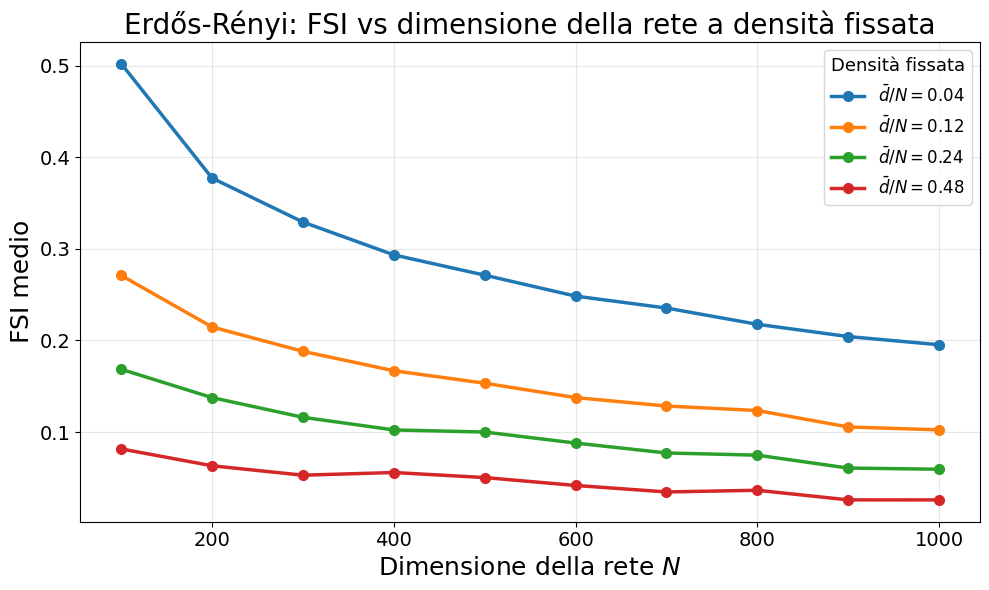

In [47]:
def plot_index_vs_size_by_density(
    df,
    index_col,
    ylabel,
    title,
    save_path=None,
):
    plt.figure(figsize=(10, 6))

    for density in sorted(df["density"].dropna().unique()):
        sub = df[df["density"] == density].sort_values("N")

        plt.plot(
            sub["N"],
            sub[index_col],
            marker="o",
            linewidth=2.5,
            markersize=7,
            label=rf"$\bar{{d}}/N={density:g}$",
        )

    plt.xlabel("Dimensione della rete $N$", fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.title(title, fontsize=20)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.grid(alpha=0.3)
    plt.legend(title="Densità fissata", fontsize=12, title_fontsize=13)

    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()


plot_index_vs_size_by_density(
    df=er_size_df,
    index_col="mean_final_freeman",
    ylabel="FSI medio",
    title="Erdős-Rényi: FSI vs dimensione della rete a densità fissata",
    save_path="figures/sensitivity/er_fsi_vs_size_by_density.png"
)

## Updating Rule: Noisy Nearest Unhappy

In [ ]:
def beta_tag(beta):
    return str(beta).replace(".", "p")


def run_noisy_nearest_beta_sensitivity(
    network_types=[
        "erdos_renyi",
        "random_regular",
        "ring_sw",
        "barabasi_albert",
    ],
    noisy_beta_values=[0.0, 0.5, 1.0, 2.0, 5.0, 10.0],
    vn_radii=[1, 2, 3, 4, 5],
    moore_radii=[1, 2, 3],
    theta=0.10,
    N=400,
    rows=20,
    cols=20,
    similar_wanted=0.50,
    beta_sw=0.10,
    max_sweeps=100,
    record_every_sweeps=1,
    stopping="no_moves_window",
    stop_window_sweeps=30,
    network_instances=1,
    runs_per_network=10,
    base_seed=12345,
    overwrite_completed=False,
    output_csv="results/sensitivity/noisy_nearest_beta_sensitivity.csv",
):

    output_path = Path(output_csv)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        results = pd.read_csv(output_path).to_dict("records")
        print(f"Loaded existing table: {output_path}")
    else:
        results = []
        print("No existing table found. Creating a new one.")

    degree_values = build_degree_grid(vn_radii, moore_radii)

    for noise_beta in noisy_beta_values:

        dynamics = f"noisy_nearest_unhappy_b{beta_tag(noise_beta)}"
        dynamics_label = rf"Noisy nearest, $\beta={noise_beta:g}$"

        for network_type in network_types:

            if network_type == "grid_vn":
                param_values = vn_radii
                param_name = "radius"

            elif network_type == "grid_moore":
                param_values = moore_radii
                param_name = "radius"

            else:
                param_values = degree_values
                param_name = "degree"

            for param in param_values:

                # -------------------------
                # Build Config
                # -------------------------

                if network_type == "grid_vn":
                    radius = param
                    degree = vn_degree(radius)

                    cfg = Config(
                        N=N,
                        rows=rows,
                        cols=cols,
                        theta=theta,
                        similar_wanted=similar_wanted,

                        network_type="grid_vn",
                        radius=radius,

                        dynamics=dynamics,
                        noise_beta=noise_beta,

                        max_sweeps=max_sweeps,
                        record_every_sweeps=record_every_sweeps,
                        stopping=stopping,
                        stop_window_sweeps=stop_window_sweeps,

                        network_instances=network_instances,
                        runs_per_network=runs_per_network,
                        base_seed=base_seed,
                        overwrite_completed=overwrite_completed,
                    )

                elif network_type == "grid_moore":
                    radius = param
                    degree = moore_degree(radius)

                    cfg = Config(
                        N=N,
                        rows=rows,
                        cols=cols,
                        theta=theta,
                        similar_wanted=similar_wanted,

                        network_type="grid_moore",
                        radius=radius,

                        dynamics=dynamics,
                        noise_beta=noise_beta,

                        max_sweeps=max_sweeps,
                        record_every_sweeps=record_every_sweeps,
                        stopping=stopping,
                        stop_window_sweeps=stop_window_sweeps,

                        network_instances=network_instances,
                        runs_per_network=runs_per_network,
                        base_seed=base_seed,
                        overwrite_completed=overwrite_completed,
                    )

                elif network_type == "erdos_renyi":
                    degree = param

                    cfg = Config(
                        N=N,
                        theta=theta,
                        similar_wanted=similar_wanted,

                        network_type="erdos_renyi",
                        avg_degree=degree,
                        p=None,

                        dynamics=dynamics,
                        noise_beta=noise_beta,

                        max_sweeps=max_sweeps,
                        record_every_sweeps=record_every_sweeps,
                        stopping=stopping,
                        stop_window_sweeps=stop_window_sweeps,

                        network_instances=network_instances,
                        runs_per_network=runs_per_network,
                        base_seed=base_seed,
                        overwrite_completed=overwrite_completed,
                    )

                elif network_type == "random_regular":
                    degree = param

                    if degree * N % 2 != 0:
                        print(f"Skipping random_regular degree={degree}: degree*N must be even.")
                        continue

                    cfg = Config(
                        N=N,
                        theta=theta,
                        similar_wanted=similar_wanted,

                        network_type="random_regular",
                        regular_degree=degree,

                        dynamics=dynamics,
                        noise_beta=noise_beta,

                        max_sweeps=max_sweeps,
                        record_every_sweeps=record_every_sweeps,
                        stopping=stopping,
                        stop_window_sweeps=stop_window_sweeps,

                        network_instances=network_instances,
                        runs_per_network=runs_per_network,
                        base_seed=base_seed,
                        overwrite_completed=overwrite_completed,
                    )

                elif network_type == "ring_sw":
                    degree = param

                    if degree % 2 != 0:
                        print(f"Skipping ring_sw degree={degree}: k must be even.")
                        continue

                    cfg = Config(
                        N=N,
                        theta=theta,
                        similar_wanted=similar_wanted,

                        network_type="ring_sw",
                        k=degree,
                        beta=beta_sw,

                        dynamics=dynamics,
                        noise_beta=noise_beta,

                        max_sweeps=max_sweeps,
                        record_every_sweeps=record_every_sweeps,
                        stopping=stopping,
                        stop_window_sweeps=stop_window_sweeps,

                        network_instances=network_instances,
                        runs_per_network=runs_per_network,
                        base_seed=base_seed,
                        overwrite_completed=overwrite_completed,
                    )

                elif network_type == "barabasi_albert":
                    degree = param

                    if degree % 2 != 0:
                        print(f"Skipping BA degree={degree}: BA average degree ≈ 2m.")
                        continue

                    m = degree // 2

                    cfg = Config(
                        N=N,
                        theta=theta,
                        similar_wanted=similar_wanted,

                        network_type="barabasi_albert",
                        ba_m=m,

                        dynamics=dynamics,
                        noise_beta=noise_beta,

                        max_sweeps=max_sweeps,
                        record_every_sweeps=record_every_sweeps,
                        stopping=stopping,
                        stop_window_sweeps=stop_window_sweeps,

                        network_instances=network_instances,
                        runs_per_network=runs_per_network,
                        base_seed=base_seed,
                        overwrite_completed=overwrite_completed,
                    )

                else:
                    raise ValueError(f"Unknown network_type: {network_type}")

                print(
                    f"\nRunning | {dynamics_label} | net={network_type} | "
                    f"{param_name}={param} | degree≈{degree} | theta={theta} | "
                    f"overwrite={overwrite_completed}"
                )

                df, aggregate = run_experiment(cfg)

                aggregate["network_type"] = network_type
                aggregate["dynamics"] = dynamics
                aggregate["dynamics_label"] = dynamics_label
                aggregate["noise_beta"] = noise_beta

                aggregate["theta"] = theta
                aggregate["degree"] = degree
                aggregate["target_degree"] = degree

                if network_type in ["grid_vn", "grid_moore"]:
                    aggregate["radius"] = param
                else:
                    aggregate["radius"] = np.nan

                if network_type == "ring_sw":
                    aggregate["beta_sw"] = beta_sw

                if network_type == "barabasi_albert":
                    aggregate["ba_m"] = degree // 2

                results.append(aggregate)

                temp_df = pd.DataFrame(results)

                duplicate_cols = [
                    "network_type",
                    "dynamics",
                    "N",
                    "theta",
                    "similar_wanted",
                    "degree",
                    "noise_beta",
                ]

                if "radius" in temp_df.columns:
                    duplicate_cols.append("radius")

                if "beta_sw" in temp_df.columns:
                    duplicate_cols.append("beta_sw")

                temp_df = temp_df.drop_duplicates(
                    subset=duplicate_cols,
                    keep="last",
                )

                temp_df = temp_df.sort_values(
                    ["network_type", "noise_beta", "degree"]
                )

                temp_df.to_csv(output_path, index=False)

                results = temp_df.to_dict("records")

                print(f"Updated table saved to: {output_path}")

    final_df = pd.DataFrame(results).sort_values(
        ["network_type", "noise_beta", "degree"]
    )

    final_df.to_csv(output_path, index=False)

    return final_df

In [ ]:
def plot_noisy_nearest_beta_vs_degree(
    df,
    network_type,
    index_col,
    ylabel,
    title=None,
    save_path=None,
):
    sub_df = df[df["network_type"] == network_type].copy()

    if len(sub_df) == 0:
        raise ValueError(f"No data found for network_type={network_type}")

    sub_df = sub_df[
        sub_df["dynamics"].astype(str).str.startswith("noisy_nearest_unhappy")
    ].copy()

    if len(sub_df) == 0:
        raise ValueError("No noisy_nearest_unhappy data found.")

    plt.figure(figsize=(10, 6))

    for noise_beta in sorted(sub_df["noise_beta"].dropna().unique()):

        sub = (
            sub_df[sub_df["noise_beta"] == noise_beta]
            .sort_values("degree")
            .copy()
        )

        sub_valid = sub.dropna(subset=["degree", index_col])

        if len(sub_valid) == 0:
            continue

        plt.plot(
            sub_valid["degree"],
            sub_valid[index_col],
            marker="o",
            linewidth=2.4,
            markersize=6,
            label=rf"$\beta={noise_beta:g}$",
        )

    plt.xlabel("Average degree", fontsize=18)
    plt.ylabel(ylabel, fontsize=18)

    if title is None:
        title = f"{network_type}: noisy nearest unhappy vs degree"

    plt.title(title, fontsize=20)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend(title=r"Noise parameter $\beta$", fontsize=11, title_fontsize=12)
    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

In [48]:
noisy_nearest_df = run_noisy_nearest_beta_sensitivity(
    network_types=["erdos_renyi"],
    noisy_beta_values=[0.0, 0.5, 1.0, 2.0, 5.0, 10.0],
    theta=0.10,
    N=400,
    similar_wanted=0.50,
    network_instances=1,
    runs_per_network=10,
    overwrite_completed=False,
    output_csv="results/sensitivity/er_noisy_nearest_beta_sensitivity.csv",
)

display(noisy_nearest_df)

Loaded existing table: results\sensitivity\er_noisy_nearest_beta_sensitivity.csv

Running | Noisy nearest, $\beta=0$ | net=erdos_renyi | degree=4 | degree≈4 | theta=0.1 | overwrite=False
Network 1/1 | Run 1/10
Network 1/1 | Run 2/10
Network 1/1 | Run 3/10
Network 1/1 | Run 4/10
Network 1/1 | Run 5/10
Network 1/1 | Run 6/10
Network 1/1 | Run 7/10
Network 1/1 | Run 8/10
Network 1/1 | Run 9/10
Network 1/1 | Run 10/10
Updated table saved to: results\sensitivity\er_noisy_nearest_beta_sensitivity.csv

Running | Noisy nearest, $\beta=0$ | net=erdos_renyi | degree=8 | degree≈8 | theta=0.1 | overwrite=False
Network 1/1 | Run 1/10
Network 1/1 | Run 2/10
Network 1/1 | Run 3/10
Network 1/1 | Run 4/10
Network 1/1 | Run 5/10
Network 1/1 | Run 6/10
Network 1/1 | Run 7/10
Network 1/1 | Run 8/10
Network 1/1 | Run 9/10
Network 1/1 | Run 10/10
Updated table saved to: results\sensitivity\er_noisy_nearest_beta_sensitivity.csv

Running | Noisy nearest, $\beta=0$ | net=erdos_renyi | degree=12 | degree≈12 | t

,network_type,dynamics,N,theta,similar_wanted,network_instances,runs_per_network,total_runs,mean_final_same,std_final_same,...,std_final_freeman,mean_final_ssi,std_final_ssi,mean_actual_degree,mean_final_sweep,dynamics_label,noise_beta,degree,target_degree,radius
0,erdos_renyi,noisy_nearest_unhappy_b0p0,400,0.1,0.5,1,10,10,0.792940,0.007369,...,0.016694,0.434908,0.026152,4.065,36.7,"Noisy nearest, $\beta=0$",0.0,4,4,NaN
1,erdos_renyi,noisy_nearest_unhappy_b0p0,400,0.1,0.5,1,10,10,0.709424,0.014738,...,0.026243,0.496108,0.032853,8.315,38.0,"Noisy nearest, $\beta=0$",0.0,8,8,NaN
2,erdos_renyi,noisy_nearest_unhappy_b0p0,400,0.1,0.5,1,10,10,0.673994,0.009369,...,0.017671,0.488590,0.024686,12.180,38.4,"Noisy nearest, $\beta=0$",0.0,12,12,NaN
3,erdos_renyi,noisy_nearest_unhappy_b0p0,400,0.1,0.5,1,10,10,0.622979,0.017596,...,0.034559,0.484925,0.032704,24.390,37.8,"Noisy nearest, $\beta=0$",0.0,24,24,NaN
4,erdos_renyi,noisy_nearest_unhappy_b0p0,400,0.1,0.5,1,10,10,0.594265,0.010085,...,0.019127,0.484210,0.037658,40.610,39.0,"Noisy nearest, $\beta=0$",0.0,40,40,NaN
5,erdos_renyi,noisy_nearest_unhappy_b0p0,400,0.1,0.5,1,10,10,0.585365,0.012620,...,0.024582,0.458987,0.020184,48.645,41.0,"Noisy nearest, $\beta=0$",0.0,48,48,NaN
6,erdos_renyi,noisy_nearest_unhappy_b0p0,400,0.1,0.5,1,10,10,0.571973,0.014444,...,0.027932,0.487369,0.024293,60.930,38.7,"Noisy nearest, $\beta=0$",0.0,60,60,NaN
7,erdos_renyi,noisy_nearest_unhappy_b0p5,400,0.1,0.5,1,10,10,0.789064,0.010907,...,0.025096,0.430646,0.031805,4.065,36.9,"Noisy nearest, $\beta=0.5$",0.5,4,4,NaN
8,erdos_renyi,noisy_nearest_unhappy_b0p5,400,0.1,0.5,1,10,10,0.710870,0.008577,...,0.017296,0.491889,0.030216,8.315,38.7,"Noisy nearest, $\beta=0.5$",0.5,8,8,NaN
9,erdos_renyi,noisy_nearest_unhappy_b0p5,400,0.1,0.5,1,10,10,0.673194,0.013955,...,0.027557,0.459589,0.032503,12.180,38.0,"Noisy nearest, $\beta=0.5$",0.5,12,12,NaN


Saved: figures/dynamics/er_noisy_nearest_fsi_vs_degree_beta.png


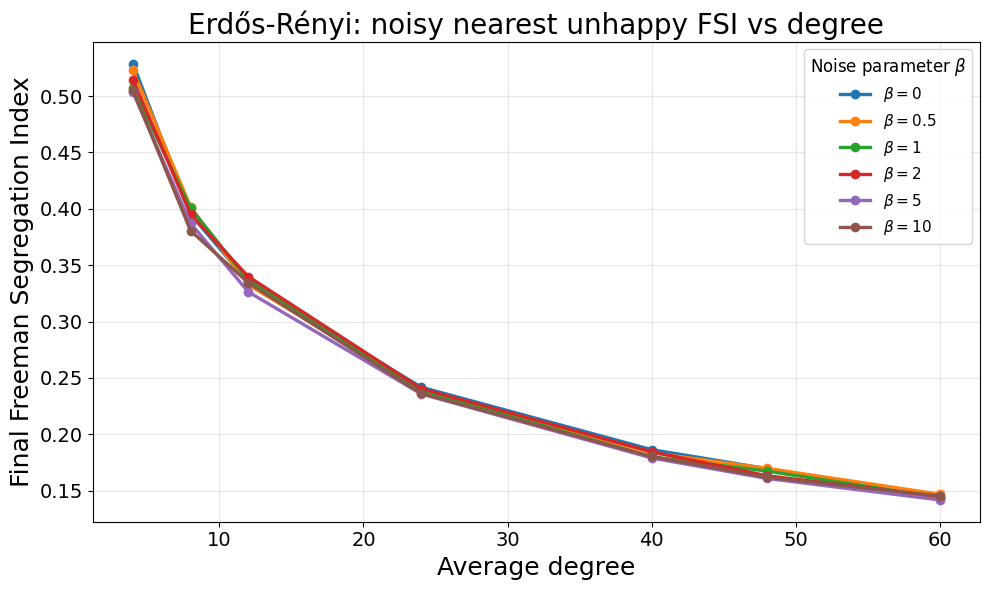

In [50]:
plot_noisy_nearest_beta_vs_degree(
    df=noisy_nearest_df,
    network_type="erdos_renyi",
    index_col="mean_final_freeman",
    ylabel="Final Freeman Segregation Index",
    title="Erdős-Rényi: noisy nearest unhappy FSI vs degree",
    save_path="figures/dynamics/er_noisy_nearest_fsi_vs_degree_beta.png",
)

